# Data Science i AI w bankowości - lista 2 część 1 - Jakość Danych
Zuzanna Nogala

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.ticker as mtick
from matplotlib.ticker import ScalarFormatter
from IPython.display import display

import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [2]:
sns.set_theme(style="whitegrid", context="notebook", palette="viridis", font_scale=0.9)
sns.set_style({'grid.linestyle': '--'})
plt.rcParams['figure.figsize'] = (10, 6)

# Funkcje

In [6]:
def color(value):
    if abs(value) <= 0.4:
        color = 'green'
    elif 0.4 < abs(value) <= 0.9:
        color = 'orange'
    elif abs(value) > 0.9:
        color = 'red'
    else:
        color = 'black'
    return 'color: {0}'.format(color)

def draw_histogram(variable: str, 
                   data_df,
                   col_dict = {'train':'#440154',
                                'test': "#21918c", 
                                'valid': '#de4968'},
                    ax=None):
    
    ax = sns.histplot(
            data=data_df, 
            x=variable, 
            hue='dataset', 
            multiple='dodge',
            bins=30, 
            stat='percent', 
            palette=col_dict,
            common_norm=False,
            shrink = 0.9,
            ax=ax 
        )
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    plt.title(f'Distribution of {variable} for each dataset')
    plt.ylabel('Share of customers (%)')
    plt.xlabel(variable)
    sns.move_legend(ax, "upper right")

def draw_boxplots(variable: str, 
                  data_df,
                  col_dict = {'train':'#440154',
                              'test': "#21918c", 
                              'valid': '#de4968'},
                ax=None):
    
    sns.boxplot(
            data=data_df, 
            y='dataset', 
            x=variable, 
            palette=col_dict,  
            hue='dataset',      
            legend=False ,
            ax=ax     
        )

    plt.title(f"Clients' {variable} Boxplots")
    plt.xlabel(f'{variable}')
    plt.ylabel('Dataset Type')

def draw_relationship_var_and_target(var: str, data_df: pd.DataFrame, col_dict: dict = {'train':'#440154', 'test': "#21918c", 'valid': '#de4968'},
                                     type_of_var: str = 'discrete'):
    
    if type_of_var == 'discrete':
        df_stats = data_df.groupby([var, 'dataset'], as_index=False).agg(set_count = ('dataset', 'count'), y_mean = ('y', 'mean'))
        df_stats['count_in_set'] = 0

        for set in ['train', 'test', 'valid']:
            df_stats.loc[df_stats.dataset == set,'count_in_set'] = df_stats.loc[df_stats.dataset == set, 'set_count'].sum()

        x_var = var
    else:
        n_unique = data_df[var].nunique()
        n_bins = min(5, n_unique) if n_unique <= 20 else 5 

        try:
            data_df[f'{var}_bins'] = pd.qcut(data_df[var], q=n_bins, duplicates = 'drop')
        except ValueError:
            data_df[f'{var}_bins'] = pd.cut(data_df[var], bins=min(2, n_unique))

        df_stats = data_df.groupby([f'{var}_bins', 'dataset'], as_index=False).agg(set_count = ('dataset', 'count'), y_mean = ('y', 'mean'))
        df_stats['count_in_set'] = 0

        for set in ['train', 'test', 'valid']:
            df_stats.loc[df_stats.dataset == set,'count_in_set'] = df_stats.loc[df_stats.dataset == set, 'set_count'].sum()

        x_var = f'{var}_bins'

    n_groups = df_stats[x_var].nunique()

    fig_width = max(10, n_groups * 1.2)
    m_size = max(3, 12 - (n_groups // 3))
    f_size = max(6, 9 - (n_groups // 5))

    fig, ax1 = plt.subplots(figsize=(fig_width, 6))
    fig.suptitle(f'The Relationship beetween the {var} Variable and y')

    sns.barplot(
        data=data_df, x=x_var, y='y', 
        hue = 'dataset', hue_order = ['train', 'test', 'valid'],
        estimator="count", 
        palette = col_dict, errorbar=None, 
        ax=ax1, alpha=0.7, width = 0.6
    )

    ax1.set_ylabel('Number of customers')
    ax1.set_xlabel(var)

    handler1, label1 = ax1.get_legend_handles_labels()
    leg1 = ax1.legend(handler1, label1, title='Customers Count', 
                    bbox_to_anchor=(1.1, 0.75), loc='upper left', frameon=True)

    ax1.grid(False)
    ax1.minorticks_off()

    ax2 = ax1.twinx()
    ax2.minorticks_off()

    sns.stripplot(
        data=df_stats, x=x_var, y='y_mean', 
        hue='dataset', hue_order = ['train', 'test', 'valid'],
        ax=ax2, dodge=True,         
        palette=col_dict, marker='D', size=m_size,          
        jitter=False, edgecolor='white', linewidth=1
    )

    handler2, label2 = ax2.get_legend_handles_labels()
    leg2 = ax2.legend(handler2, label2, title='Average Target Value', 
                    bbox_to_anchor=(1.09, 0.5), loc='upper left', frameon=True)
    ax1.add_artist(leg1)

    ax2.set_ylim(0, df_stats['y_mean'].max() * 1.2)

    ymin, ymax = ax1.get_ylim()
    ax1.set_ylim(ymin, ymax * 1.1)
    plt.show()

# Wstęp

Celem raportu jest analiza danych dotyczących telefonicznych kampanii marketingowych portugalskiej instytucji bankowej prowadzonej od maja 2008 do listopada 2010. 

Zakres analiz obejmuje:

* **interpretację zmiennych**: wyjaśnienie znaczenia poszczególnych cech w zbiorze danych;

* **weryfikację jakości danych**: identyfikację duplikatów oraz brakujących wartości;

* **eksploracyjną analizę danych**: badanie rozkładów, statystyk opisowych oraz analizę korelacji między zmiennymi;

* **analizę zależności**: zbadanie relacji pomiędzy cechami diagnostycznymi a zmienną objaśnianą.

Głównym celem opracowania jest przygotowanie bazy informacyjnej pod budowę modelu klasyfikacyjnego XGBoost. Algorytm ten zostanie wykorzystany do przewidywania, czy dany klient zdecyduje się na założenie lokaty terminowej na podstawie jego cech demograficznych oraz historii kontaktów marketingowych.

Proces właściwej budowy modelu oraz selekcji zmiennych zostanie szczegółowo opisany w kolejnej części tego raportu, tj. "Data Science i AI w bankowości - lista 2 część 2 - Dobór Modelu XGBoost".

# 1. Opis i interpretacja zmiennych w zbiorze danych

Zgodnie z zapowiedzią we wstępie, przedmiotem analizy są dane pochodzące z kampanii marketingowych prowadzonych przez portugalską instytucję bankową. Zbiór danych zawiera 45 211 unikalnych rekordów, z których każdy odpowiada pojedynczej interakcji telefonicznej z klientem, które zostały wykonane od maja 2008 do listopada 2010. Każdy kontakt telefoniczny został opisany za pomocą 17 zmiennych oraz zmienną docelową 'y', która informuje czy klient założył lokatę (wartość 1) czy nie (wartość 0).

In [7]:
df = pd.read_csv("bank-full.csv", sep = ';')

df['contact_id'] = df.index
df['y'] = df['y'].map({'no': 0, 'yes': 1})
df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,contact_id
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0,2
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0,3
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0,4
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,0,5
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,0,6
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,0,7
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,0,8
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,0,9


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   age         45211 non-null  int64
 1   job         45211 non-null  str  
 2   marital     45211 non-null  str  
 3   education   45211 non-null  str  
 4   default     45211 non-null  str  
 5   balance     45211 non-null  int64
 6   housing     45211 non-null  str  
 7   loan        45211 non-null  str  
 8   contact     45211 non-null  str  
 9   day         45211 non-null  int64
 10  month       45211 non-null  str  
 11  duration    45211 non-null  int64
 12  campaign    45211 non-null  int64
 13  pdays       45211 non-null  int64
 14  previous    45211 non-null  int64
 15  poutcome    45211 non-null  str  
 16  y           45211 non-null  int64
 17  contact_id  45211 non-null  int64
dtypes: int64(9), str(9)
memory usage: 6.2 MB


Dostępne zmienne objaśniające zostały podzielone na trzy grupy tematyczne: 
* dane demograficzne klienta, 
* informacje o bieżącej kampanii,
* oraz wskaźniki mówiące o historii współpracy z danym klientem

### Dane o kliencie 
1. age (numeryczna): wiek klienta;
2. job (kategoryczna): rodzaj wykonywanego zawodu ("admin.", "unknown", "unemployed", "management",
"housemaid", "entrepreneur", "student", "blue-collar", "self-employed", "retired",
"technician", "services");
3. marital (kategoryczna): stan cywilny ("married" (zamężny/żonaty), "divorced" (rozwiedziony/wdowiec), "single" (singiel));
4. education (kategoryczna): poziom wykształcenia ("unknown", "secondary", "primary",
"tertiary");
5. default (binarna): informacja, czy klient ma zaległości w spłacie kredytu ("yes", "no");
6. balance (numeryczna): średnie roczne saldo na koncie klienta (w euro);
7. housing (binarna): informacja, czy klient ma kredyt hipoteczny ("yes", "no");
8. loan (binarna): informacja, czy klient ma kredyt gotówkowy ("yes", "no");


### Informacje o bieżącej kampanii
9. contact_id (numeryczna): identyfikator kontaktu z klientem;
10. contact (kategoryczna): typ komunikacji ("unknown", "telephone", "cellular");
11. day (numeryczna): dzień ostatniego kontaktu w miesiącu;
12. month (kategoryczna): miesiąc ostatniego kontaktu ("jan", "feb", "mar", ..., "nov", "dec");
13. duration (numeryczna): czas trwania ostatniego kontaktu (w sekundach);
14. campaign (numeryczna): liczba kontaktów wykonanych w tej kampanii dla danego klienta;

### Wskaźniki mówiące o historii współpracy z danym klientem
15. pdays (numeryczna): liczba dni od ostatniego kontaktu klienta w poprzedniej kampanii (wartość -1
oznacza brak wcześniejszego kontaktu);
16. previous (numeryczna): liczba kontaktów wykonanych przed tą kampanią dla danego klienta;
17. poutcome (kategoryczna): wynik poprzedniej kampanii marketingowej (kategorie: "unknown", "other",
"failure", "success").

# 2. Jakość danych

W ramach oceny jakości danych zweryfikowano występowanie brakujących wartości oraz rekordów zduplikowanych. Przeprowadzona analiza wykazała, że zbiór jest kompletny i unikalny, co pozwala na dalsze analizy bez konieczności stosowania metod imputacji czy czyszczenia danych.

In [11]:
print("Liczba obserwacji brakujących dla kadej zmiennej:")
print(df.isna().sum())

print(" ")
print("Liczba rekordów zduplikowanych:")
print(df.duplicated().sum())

Liczba obserwacji brakujących dla kadej zmiennej:
age           0
job           0
marital       0
education     0
default       0
balance       0
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
y             0
contact_id    0
dtype: int64
 
Liczba rekordów zduplikowanych:
0


Przed przystąpieniem do dalszych analiz, tj. analizy eksploracyjnej (rozdział 3) wszystkie zmienne kategoryczne zostały poddane kodowaniu numerycznemu. Zabieg ten umożliwia uwzględnienie tych zmiennych w wyznaczaniu statystyk opisowych oraz pozwala na zbadanie współczynników korelacji dla wszystkich danych.

In [9]:
df_labeled = df.copy()

encoder = LabelEncoder()

for col in df_labeled.select_dtypes(include=['object', 'string']).columns:
    df_labeled[col] = encoder.fit_transform(df_labeled[col])

df_labeled.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,contact_id
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0,1
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0,2
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0,3
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0,4
5,35,4,1,2,0,231,1,0,2,5,8,139,1,-1,0,3,0,5
6,28,4,2,2,0,447,1,1,2,5,8,217,1,-1,0,3,0,6
7,42,2,0,2,1,2,1,0,2,5,8,380,1,-1,0,3,0,7
8,58,5,1,0,0,121,1,0,2,5,8,50,1,-1,0,3,0,8
9,43,9,2,1,0,593,1,0,2,5,8,55,1,-1,0,3,0,9


In [10]:
df_labeled.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   age         45211 non-null  int64
 1   job         45211 non-null  int64
 2   marital     45211 non-null  int64
 3   education   45211 non-null  int64
 4   default     45211 non-null  int64
 5   balance     45211 non-null  int64
 6   housing     45211 non-null  int64
 7   loan        45211 non-null  int64
 8   contact     45211 non-null  int64
 9   day         45211 non-null  int64
 10  month       45211 non-null  int64
 11  duration    45211 non-null  int64
 12  campaign    45211 non-null  int64
 13  pdays       45211 non-null  int64
 14  previous    45211 non-null  int64
 15  poutcome    45211 non-null  int64
 16  y           45211 non-null  int64
 17  contact_id  45211 non-null  int64
dtypes: int64(18)
memory usage: 6.2 MB


# 3. Analiza eksploracyjna danych

W tym rozdziale zostanie przeprowadzona analiza eksploracyjna danych. Na potrzeby dalszych estapów prac oraz późniejszego trenowania klasyfikacyjnego modelu XGBoost dostępny zbiór danych został podzielony na trzy grupy: treningową, walidacyjną oraz testową. Podziału dokonano w proporcji 60:20:20, co oznacza, że model będzie trenowany na 60% ogółu danych, natomiast pozostałe 40% posłuży do walidacji i końcowej oceny skuteczności algorytmu. 

W dalszej części raportu przeprowadzona zostanie analiza zmiennych objaśniających (tj. wykluczamy zmienne contact_id oraz zmieną celu y) w każdym z wydzielonych podzbiorów. Wówczas zweryfikujemy, czy zastosowany podział gwarantuje spójność rozkładów oraz czy wyodrębnione próbki są względem siebie reprezentatywne.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(df_labeled.drop(columns = ['y', 'contact_id']), 
                                                    df_labeled.y, test_size=0.4, random_state=20)
X_test, X_valid, y_test, y_valid = train_test_split(X_test, 
                                                    y_test, test_size=0.5, random_state=20)

In [13]:
print(f"Rozmiar próbki treningowej: {X_train.shape} - {X_train.shape[0]/df.shape[0]:.2%} - średnia zmiennej docelowej: {y_train.mean():.2%}")
print(f"Rozmiar próbki testowej: {X_test.shape} - {X_test.shape[0]/df.shape[0]:.2%} - średnia zmiennej docelowej: {y_test.mean():.2%}")
print(f"Rozmiar próbki walidacyjnej: {X_valid.shape} - {X_valid.shape[0]/df.shape[0]:.2%} - średnia zmiennej docelowej: {y_valid.mean():.2%}")

Rozmiar próbki treningowej: (27126, 16) - 60.00% - średnia zmiennej docelowej: 11.80%
Rozmiar próbki testowej: (9042, 16) - 20.00% - średnia zmiennej docelowej: 11.81%
Rozmiar próbki walidacyjnej: (9043, 16) - 20.00% - średnia zmiennej docelowej: 11.29%


## 3.1 Analiza korelacji pomiędzy zmiennymi

W celu oceny korelacji Spearmana pomiędzy cechami wyznaczono macierze korelacji pomiędzy zmiennymi w zbiorze treningowym, testowym i walidacyjnym. Wyniki poddano kategoryzacji wizualnej według następujących kryteriów:

* Korelacja niska (niebieski): $|r| < 40\%$. Wskazuje na brak istotnej zależności

* Korelacja średnia (pomarańczowy): $40\% \leq |r| \leq 90\%$. Sugeruje wyraźny, ale niekrytyczny związek między zmiennymi.

* Korelacja wysoka (czerwony): $|r| > 90\%$. Sygnalizuje silną zależność.

Poniżej przedstawiono macierze korelacji dla zmiennych w zbiorze treningowym, testowym i walidacyjnym, umożliwiając porównanie stabilności korelacji w różnych podziałach danych.

In [15]:
corr = X_train.corr(method='spearman')
corr.style.map(color)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
age,1.000000,-0.007643,-0.442389,-0.122473,-0.008978,0.095787,-0.159100,0.001519,0.052110,-0.005239,-0.031657,-0.035340,0.039423,-0.021136,-0.015357,0.016352
job,-0.007643,1.000000,0.058030,0.175298,-0.006625,0.030658,-0.132114,-0.033111,-0.081799,0.028871,-0.083609,0.000466,0.013002,-0.011589,-0.004474,0.008030
marital,-0.442389,0.058030,1.000000,0.118449,-0.007196,0.017068,-0.019435,-0.042115,-0.041451,-0.009929,-0.007814,0.023753,-0.031496,0.034896,0.034329,-0.032562
education,-0.122473,0.175298,0.118449,1.000000,-0.016292,0.077106,-0.089475,-0.047840,-0.133428,0.028711,-0.052363,-0.003268,-0.001633,0.026745,0.035869,-0.032514
default,-0.008978,-0.006625,-0.007196,-0.016292,1.000000,-0.171970,-0.003759,0.080712,0.014283,0.015158,0.007818,-0.009074,0.009510,-0.037206,-0.038457,0.037741
balance,0.095787,0.030658,0.017068,0.077106,-0.171970,1.000000,-0.071268,-0.134028,-0.033773,-0.000125,0.025086,0.042786,-0.031260,0.065151,0.075016,-0.070182
housing,-0.159100,-0.132114,-0.019435,-0.089475,-0.003759,-0.071268,1.000000,0.043939,0.180645,-0.026027,0.269171,0.002030,-0.037167,0.084205,0.065485,-0.077694
loan,0.001519,-0.033111,-0.042115,-0.047840,0.080712,-0.134028,0.043939,1.000000,-0.009592,0.012218,0.006978,-0.012744,-0.004341,-0.029861,-0.030965,0.027755
contact,0.052110,-0.081799,-0.041451,-0.133428,0.014283,-0.033773,0.180645,-0.009592,1.000000,-0.022247,0.322395,-0.048472,0.005031,-0.276722,-0.275904,0.278167
day,-0.005239,0.028871,-0.009929,0.028711,0.015158,-0.000125,-0.026027,0.012218,-0.022247,1.000000,0.009859,-0.054542,0.133342,-0.095206,-0.090222,0.091356


In [16]:
corr = X_test.corr(method='spearman')
corr.style.map(color)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
age,1.000000,-0.013043,-0.450463,-0.107168,-0.023086,0.095904,-0.146354,-0.004998,0.062499,-0.020006,-0.023273,-0.025413,0.040335,-0.022781,-0.018436,0.018922
job,-0.013043,1.000000,0.054101,0.160587,0.001135,0.025354,-0.121493,-0.042310,-0.078253,0.007962,-0.079091,0.014936,0.010365,0.000045,0.004484,-0.002691
marital,-0.450463,0.054101,1.000000,0.118963,-0.008223,0.036925,-0.020911,-0.067332,-0.057202,-0.002249,-0.017356,0.012065,-0.020141,0.012425,0.012793,-0.010765
education,-0.107168,0.160587,0.118963,1.000000,0.004518,0.060759,-0.095610,-0.046305,-0.121848,0.007548,-0.048950,0.005250,-0.004897,0.028374,0.036866,-0.032412
default,-0.023086,0.001135,-0.008223,0.004518,1.000000,-0.158592,-0.013096,0.073422,0.009773,0.002780,0.004758,-0.012280,0.017642,-0.032213,-0.035108,0.033214
balance,0.095904,0.025354,0.036925,0.060759,-0.158592,1.000000,-0.061051,-0.115007,-0.026977,0.001516,0.026597,0.057789,-0.042898,0.061554,0.072948,-0.069066
housing,-0.146354,-0.121493,-0.020911,-0.095610,-0.013096,-0.061051,1.000000,0.029781,0.173479,-0.020165,0.260720,-0.005773,-0.044589,0.078329,0.060045,-0.073821
loan,-0.004998,-0.042310,-0.067332,-0.046305,0.073422,-0.115007,0.029781,1.000000,-0.026246,0.023209,-0.007707,-0.034074,0.019066,-0.029960,-0.032047,0.027635
contact,0.062499,-0.078253,-0.057202,-0.121848,0.009773,-0.026977,0.173479,-0.026246,1.000000,-0.025934,0.307407,-0.019801,0.030335,-0.284863,-0.285195,0.286088
day,-0.020006,0.007962,-0.002249,0.007548,0.002780,0.001516,-0.020165,0.023209,-0.025934,1.000000,0.011430,-0.065643,0.140018,-0.093248,-0.087895,0.089112


In [17]:
corr = X_valid.corr(method='spearman')
corr.style.map(color)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
age,1.000000,-0.005109,-0.436368,-0.103165,-0.023577,0.098821,-0.148130,-0.023461,0.046762,-0.008859,-0.044390,-0.034871,0.026779,-0.000985,0.005188,-0.001852
job,-0.005109,1.000000,0.046999,0.197224,-0.007472,0.030766,-0.138905,-0.030340,-0.079674,0.017057,-0.083638,0.010184,0.013828,-0.009656,-0.002011,0.006333
marital,-0.436368,0.046999,1.000000,0.122040,0.001536,0.013281,-0.006127,-0.048791,-0.029976,0.000761,0.014763,0.003786,-0.037218,0.011496,0.013045,-0.011751
education,-0.103165,0.197224,0.122040,1.000000,-0.015086,0.084214,-0.107648,-0.049346,-0.116954,0.029421,-0.051455,-0.013697,0.001629,0.022722,0.029098,-0.027384
default,-0.023577,-0.007472,0.001536,-0.015086,1.000000,-0.163985,-0.005826,0.070481,0.015461,0.000230,0.002076,0.004066,0.024899,-0.046337,-0.045875,0.046882
balance,0.098821,0.030766,0.013281,0.084214,-0.163985,1.000000,-0.066461,-0.127223,-0.042810,0.005758,0.036077,0.026805,-0.018038,0.091415,0.099703,-0.097290
housing,-0.148130,-0.138905,-0.006127,-0.107648,-0.005826,-0.066461,1.000000,0.044860,0.175544,-0.039863,0.258396,0.025675,-0.032889,0.073958,0.054001,-0.065866
loan,-0.023461,-0.030340,-0.048791,-0.049346,0.070481,-0.127223,0.044860,1.000000,-0.004711,0.000903,0.000535,0.006417,0.001928,-0.028268,-0.028533,0.025658
contact,0.046762,-0.079674,-0.029976,-0.116954,0.015461,-0.042810,0.175544,-0.004711,1.000000,-0.044396,0.325443,-0.018564,-0.005380,-0.282452,-0.281619,0.283468
day,-0.008859,0.017057,0.000761,0.029421,0.000230,0.005758,-0.039863,0.000903,-0.044396,1.000000,-0.007498,-0.061228,0.157568,-0.082149,-0.080197,0.076971


Z analizy powyzszych macierzy korelacji wynika, ze w przeważającej większości zmienne są nieskorelowane. Wyraźne odstępstwa od tej reguły zaobserwowano jedynie w kilku obszarach:

* Umiarkowana zależność (strefa pomarańczowa): Występuje pomiędzy zmiennymi age oraz marital. Jest to naturalne zjawisko społeczne – status cywilny zmienia się wraz z wiekiem (przejście z grupy osób stanu wolnego (marital=2) do osób zamężnych /żonatych (marital=1) lub rozwiedzionych (marital=0)).

* Wysoka korelacja (strefa czerwona): Silne zależności ($|r| \approx 1$) odnotowano dla zmiennych: pdays, previous oraz poutcome. Wynika to z faktu, ze wszystkie wyzej wymienione zmienne opisują historię kontaktów z klientem w ramach poprzednich kampanii marketingowych. Z tego powodu niosą one niemal identyczną informację, wskazana jest redukcja tych cech przed etapem modelowania.

## 3.2 Analiza rozkładów zmiennych i wartości odstających

W tej sekcji skupimy się na:
* analizie porównawczej rozkładów zmiennych w trzech wyodrębnionych grupach danych na bazie statystyk opisowych, histogramów oraz wykresów pudełkowych.
* zwięzłej charakterystyce rozkładów poszczególnych zmiennych.

Szczegółowa analiza oraz wnioski znajdują się bezpośrednio pod prezentowanymi wykresami.

### 3.2.1 Wartości statystyk opisowych

W poniższej tabeli zestawiono statystyki opisowe dla analizowanych zmiennych numerycznych. Zestawienie obejmuje: liczebność, średnią arytmetyczną, odchylenie standardowe, wartości skrajne (minimum i maksimum) oraz kwartyle (25%, 50% i 75%).

In [18]:
df_labeled.describe()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,contact_id
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,4.339762,1.167725,1.224813,0.018027,1362.272058,0.555838,0.160226,0.640242,15.806419,5.523014,258.163080,2.763841,40.197828,0.580323,2.559974,0.116985,22605.000000
std,10.618762,3.272657,0.608230,0.747997,0.133049,3044.765829,0.496878,0.366820,0.897951,8.322476,3.006911,257.527812,3.098021,100.128746,2.303441,0.989059,0.321406,13051.435847
min,18.000000,0.000000,0.000000,0.000000,0.000000,-8019.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,1.000000,1.000000,1.000000,0.000000,72.000000,0.000000,0.000000,0.000000,8.000000,3.000000,103.000000,1.000000,-1.000000,0.000000,3.000000,0.000000,11302.500000
50%,39.000000,4.000000,1.000000,1.000000,0.000000,448.000000,1.000000,0.000000,0.000000,16.000000,6.000000,180.000000,2.000000,-1.000000,0.000000,3.000000,0.000000,22605.000000
75%,48.000000,7.000000,2.000000,2.000000,0.000000,1428.000000,1.000000,0.000000,2.000000,21.000000,8.000000,319.000000,3.000000,-1.000000,0.000000,3.000000,0.000000,33907.500000
max,95.000000,11.000000,2.000000,3.000000,1.000000,102127.000000,1.000000,1.000000,2.000000,31.000000,11.000000,4918.000000,63.000000,871.000000,275.000000,3.000000,1.000000,45210.000000


### 3.3.2 Wykresy rozkładów zmiennych

In [19]:
X_train['dataset'] = 'train'
X_test['dataset'] = 'test'
X_valid['dataset'] = 'valid'

df_all = pd.concat([X_train, X_test, X_valid])
df_all['y'] = pd.concat([y_train, y_test, y_valid])

Rozkłady (histogramy) i wykresy pudełkowe dla poszczególnych zmiennych w podziale na grupy przedstawiono poniżej.

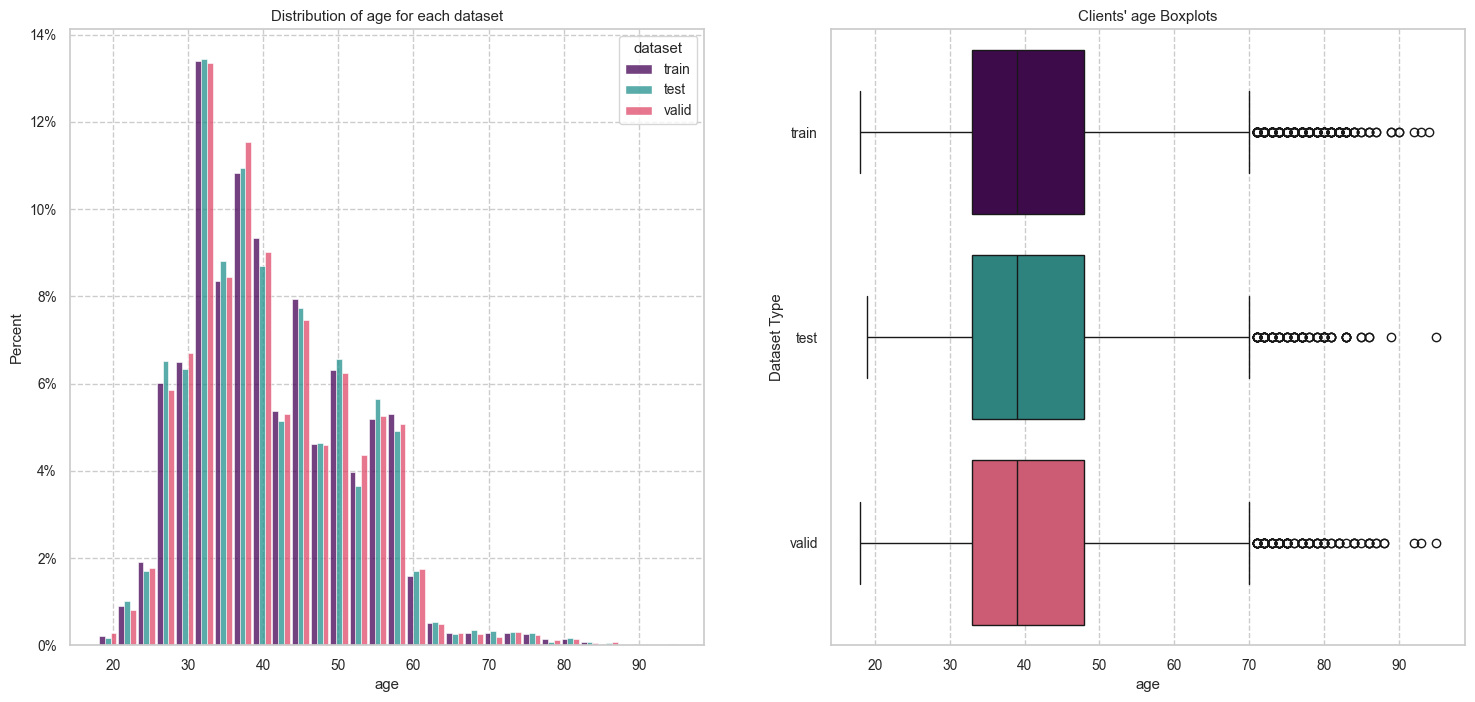

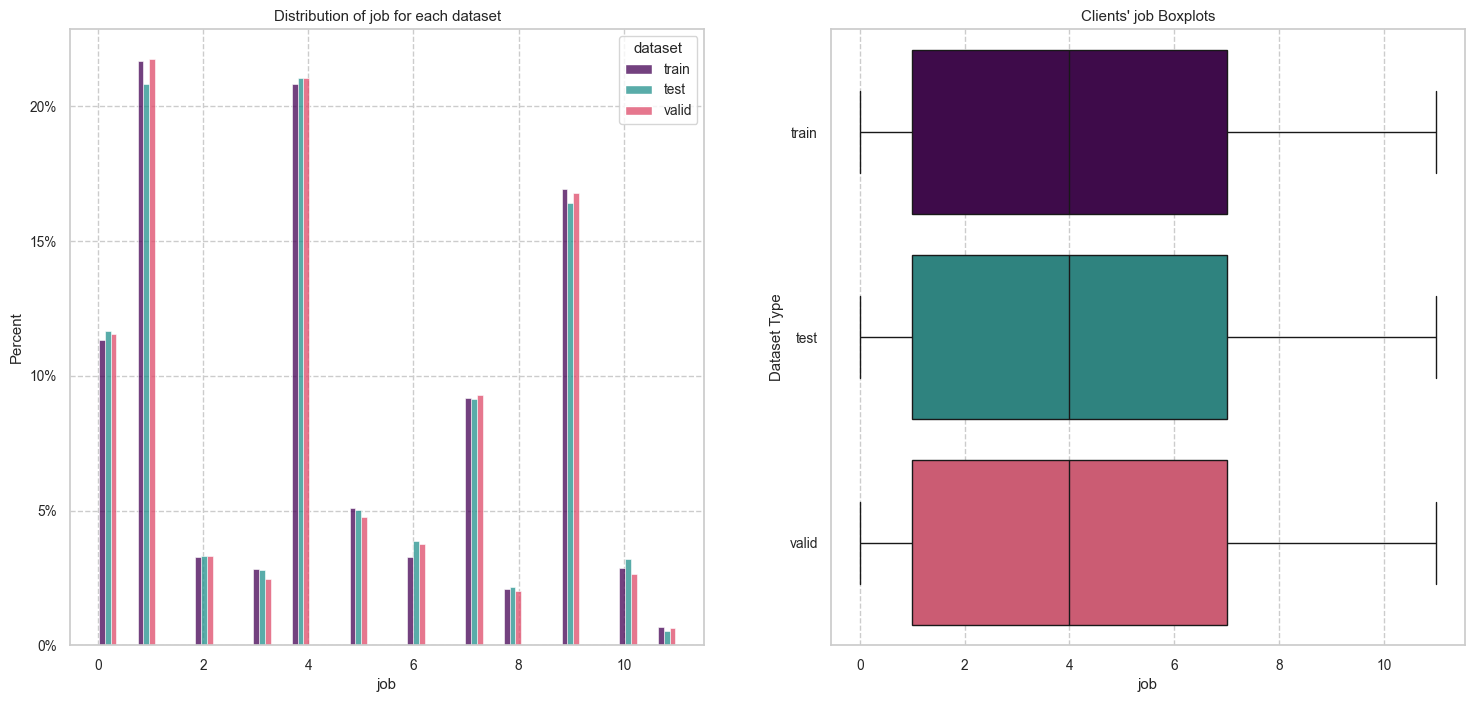

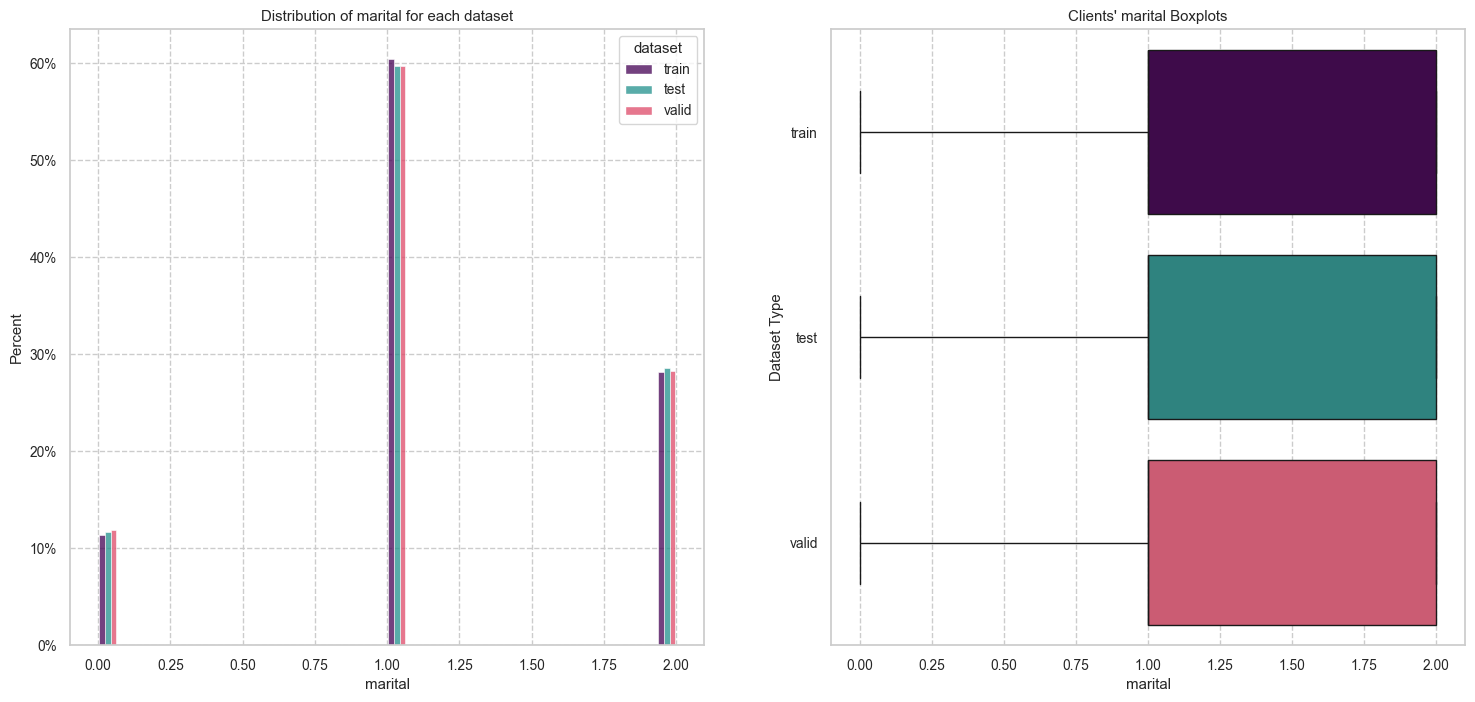

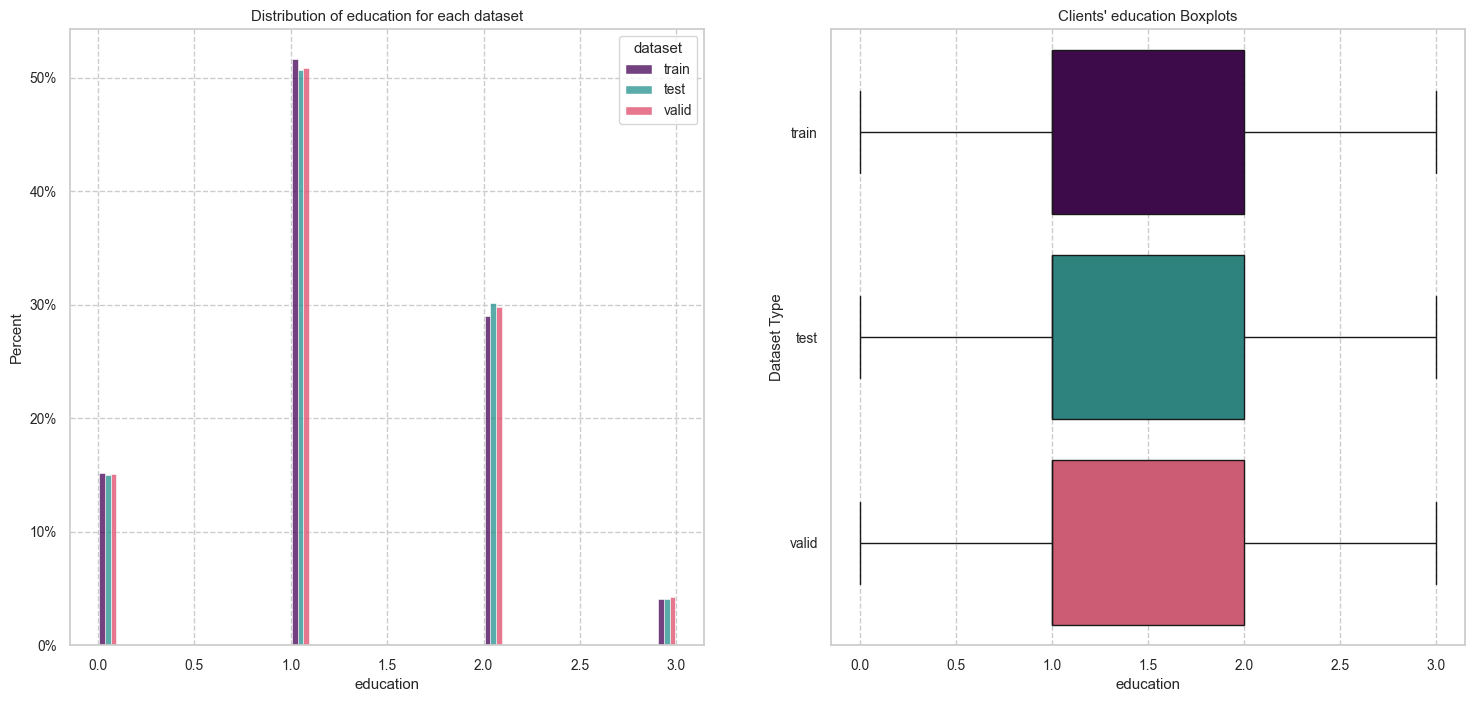

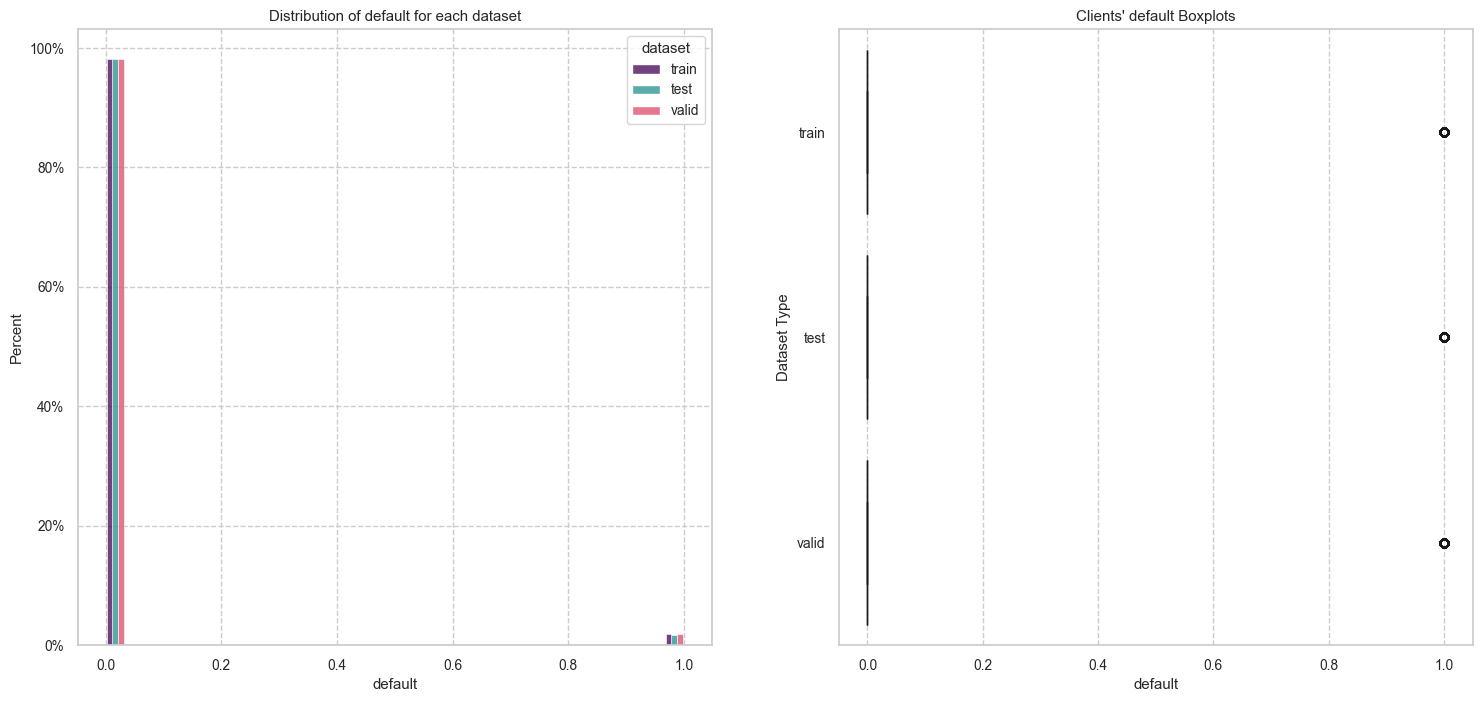

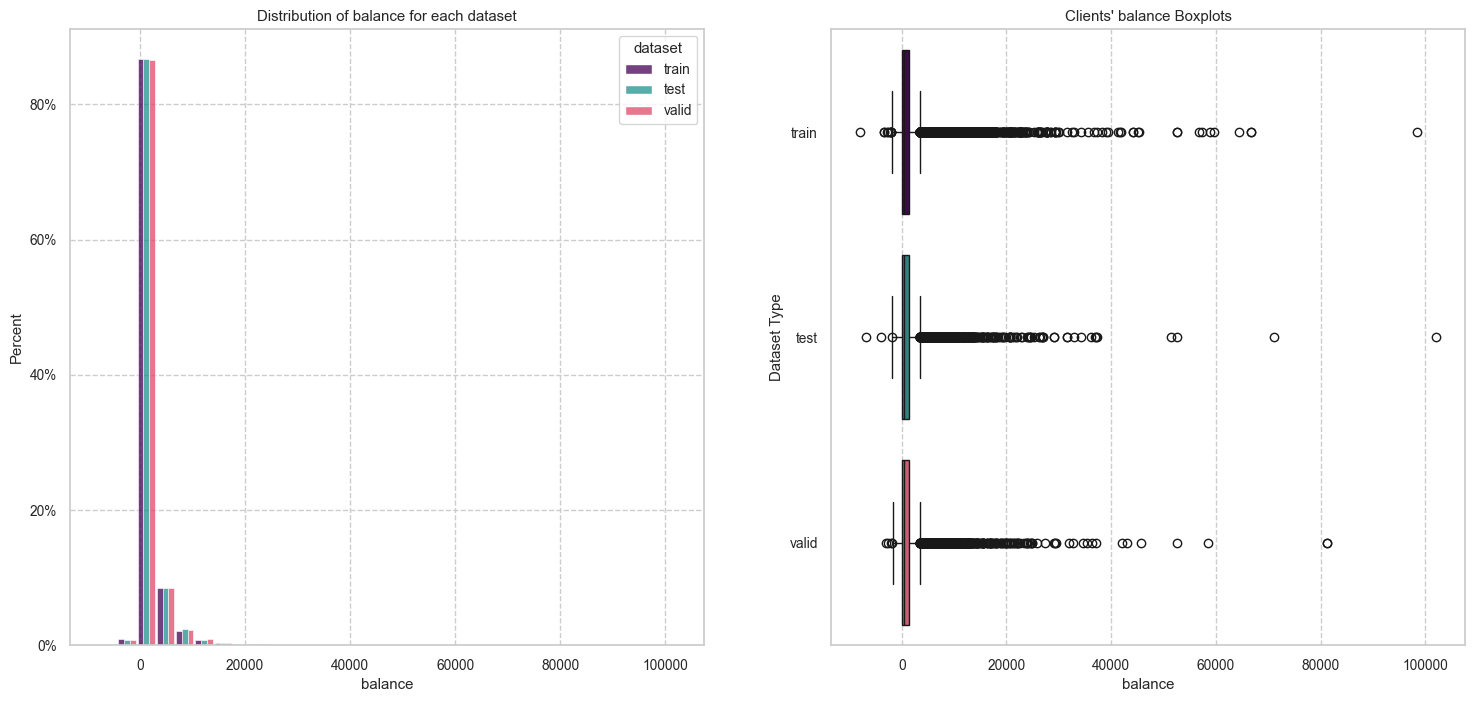

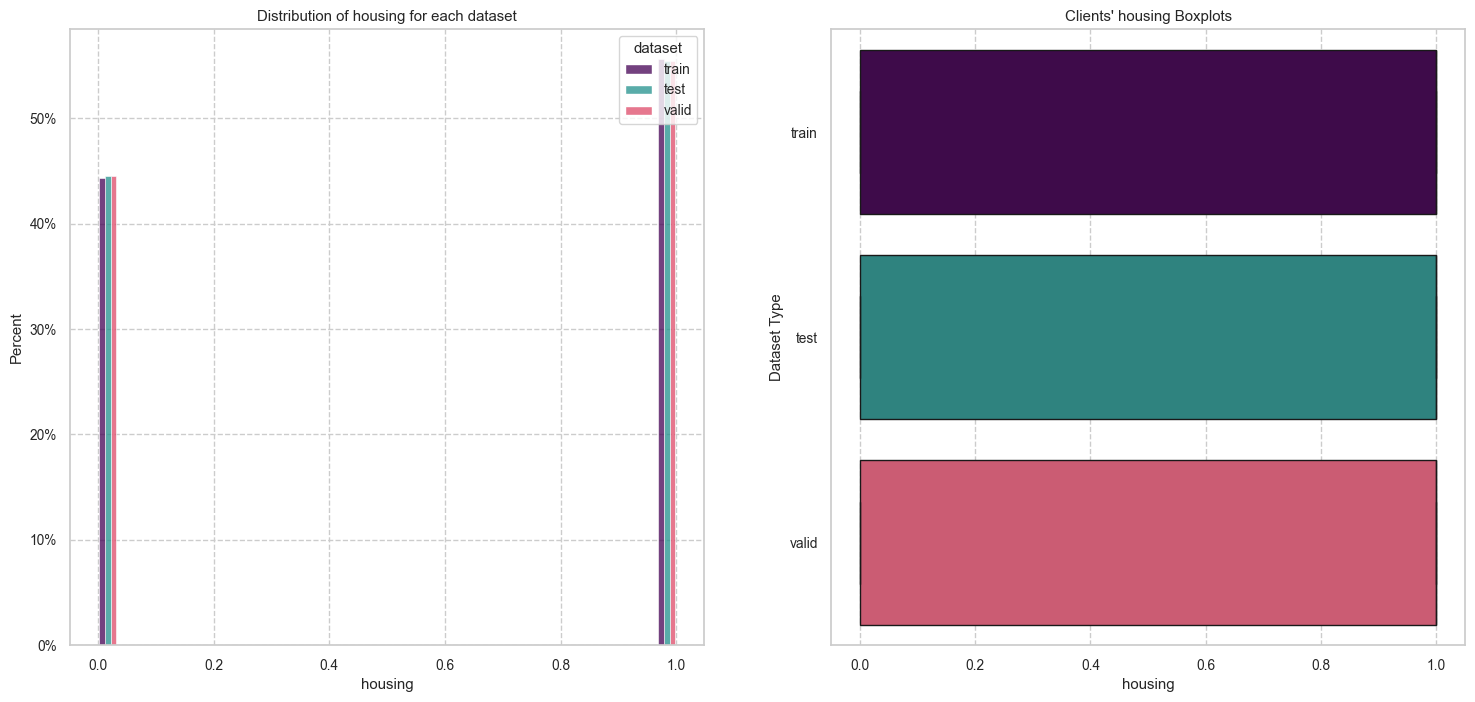

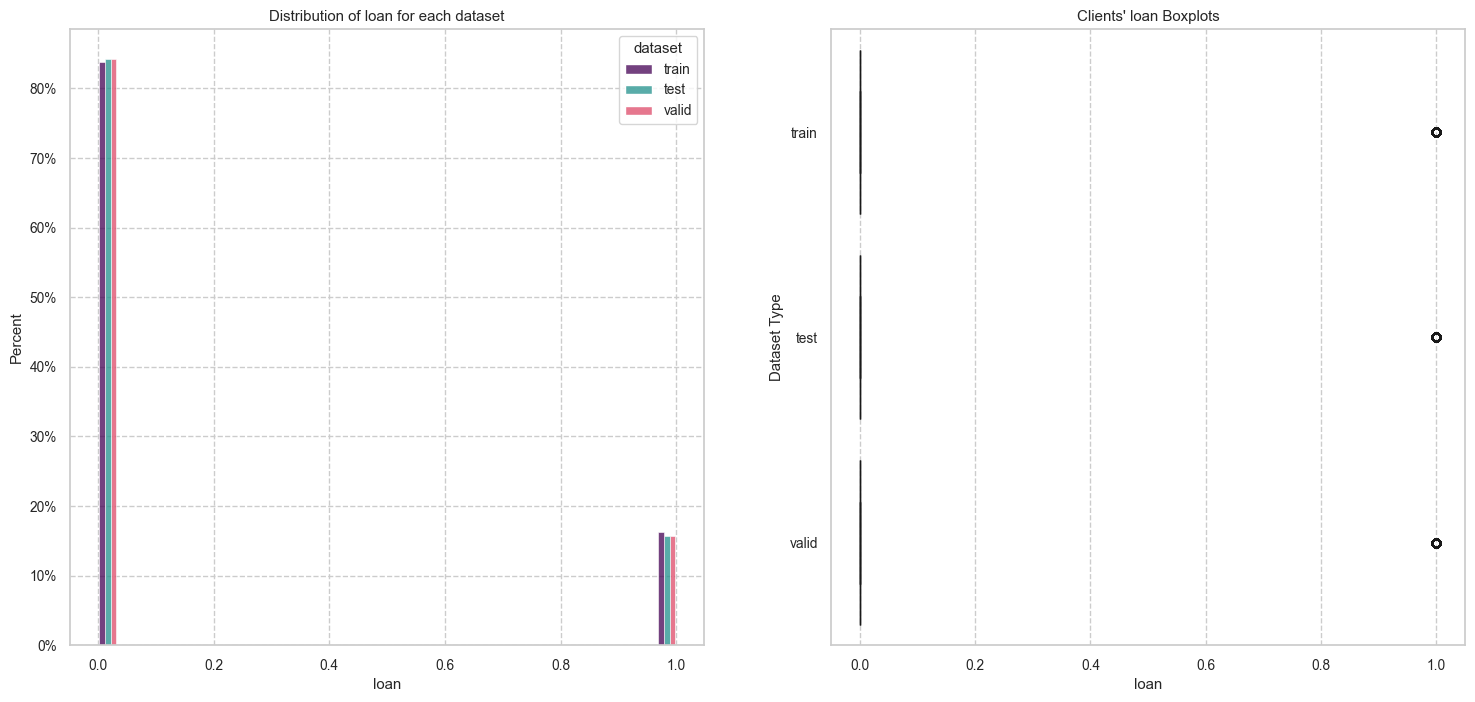

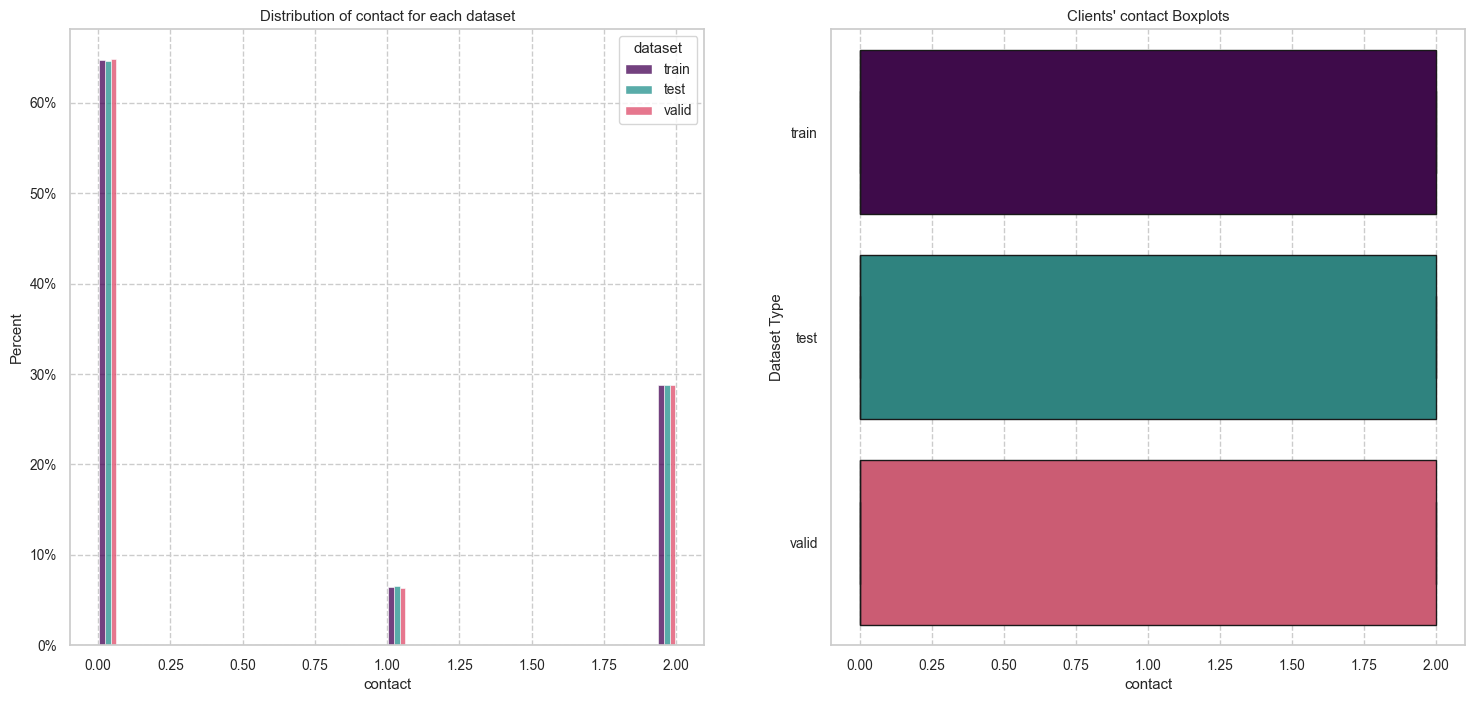

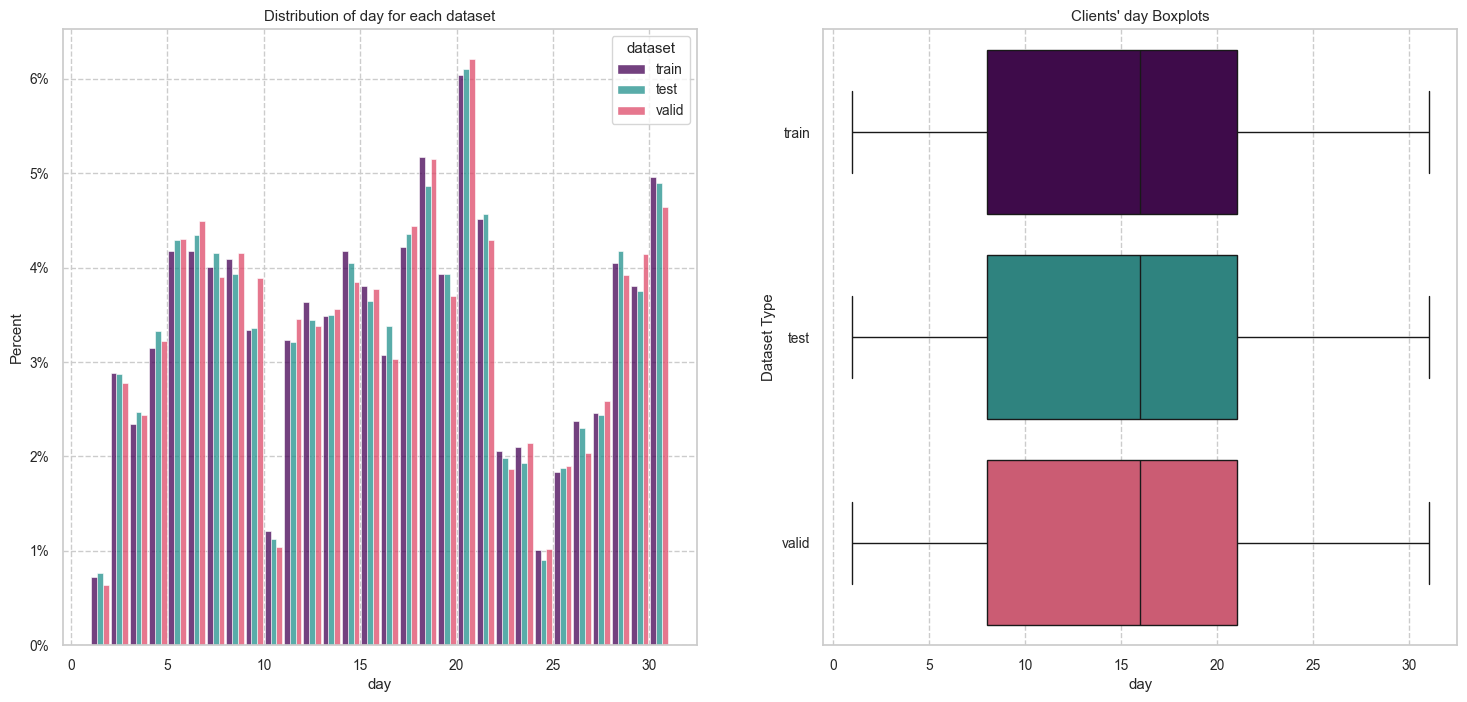

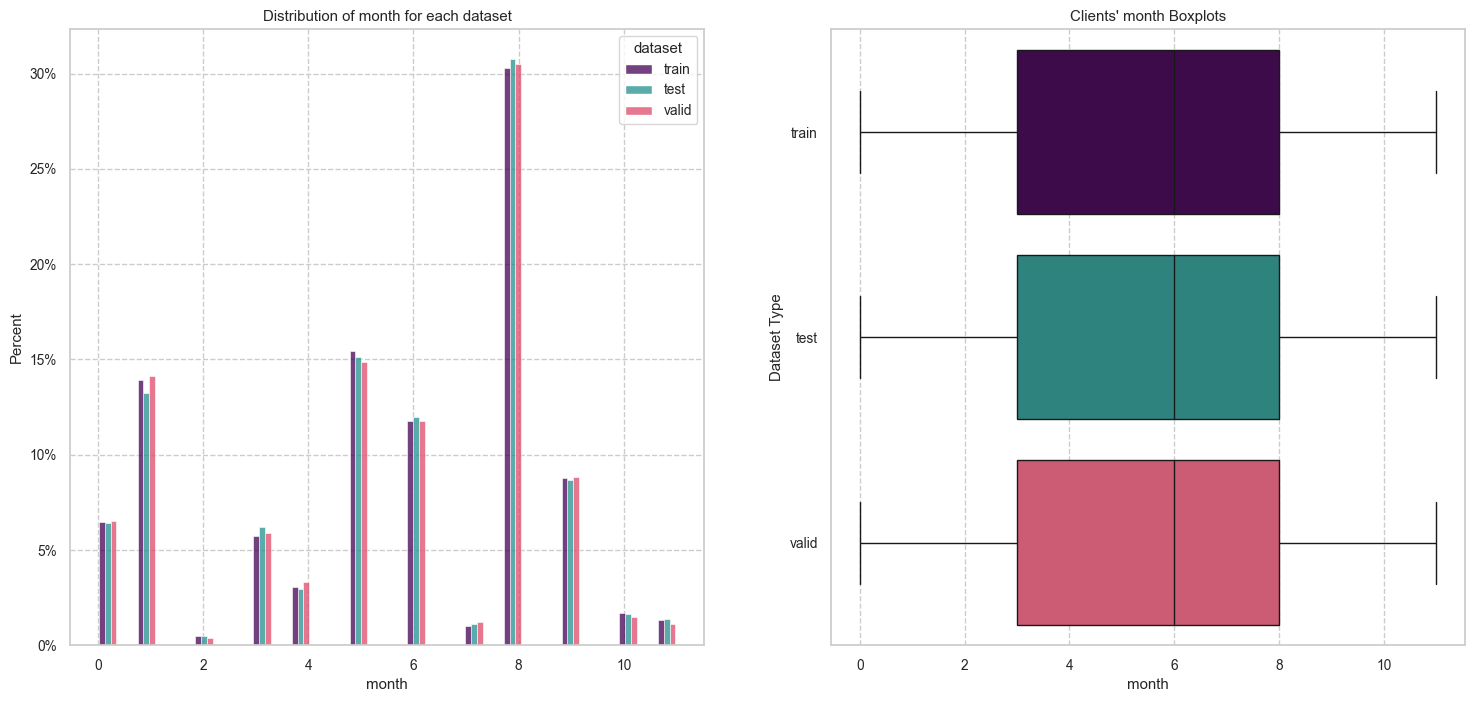

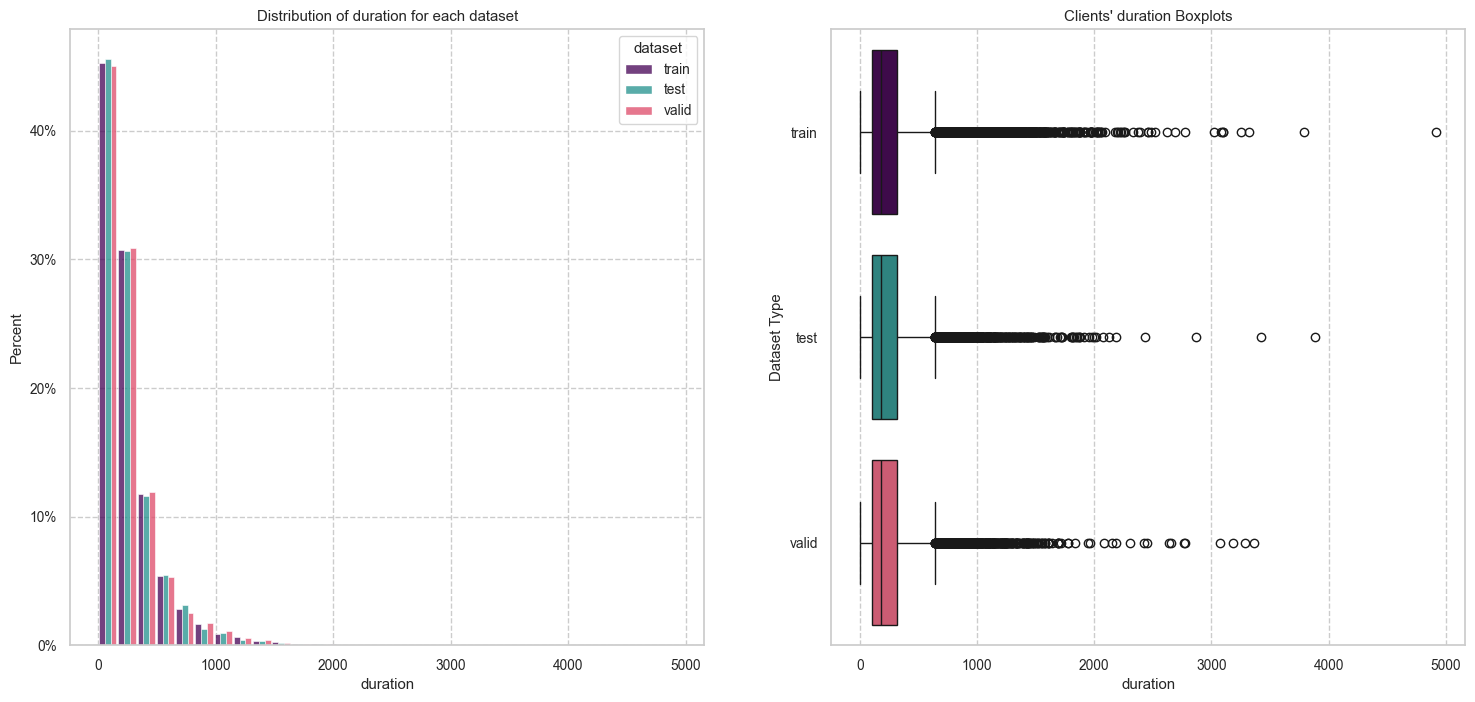

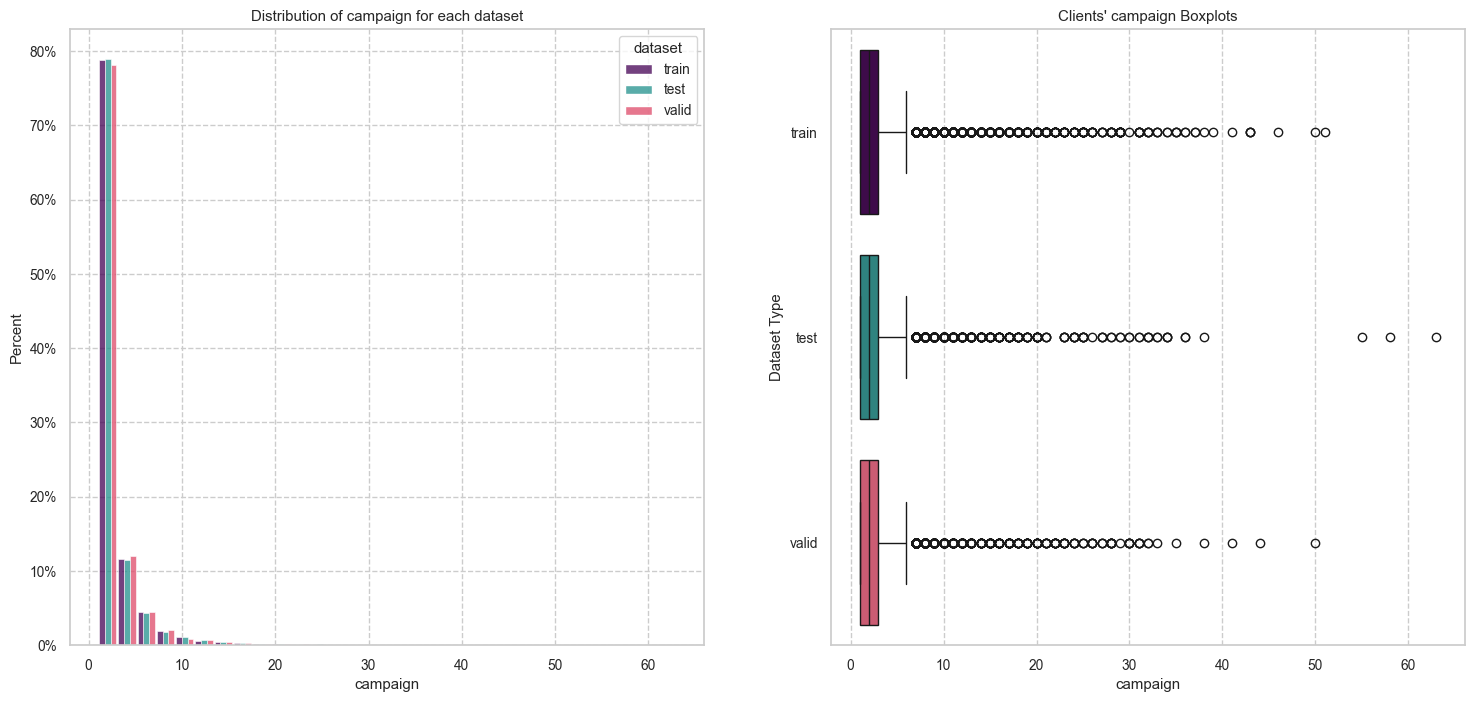

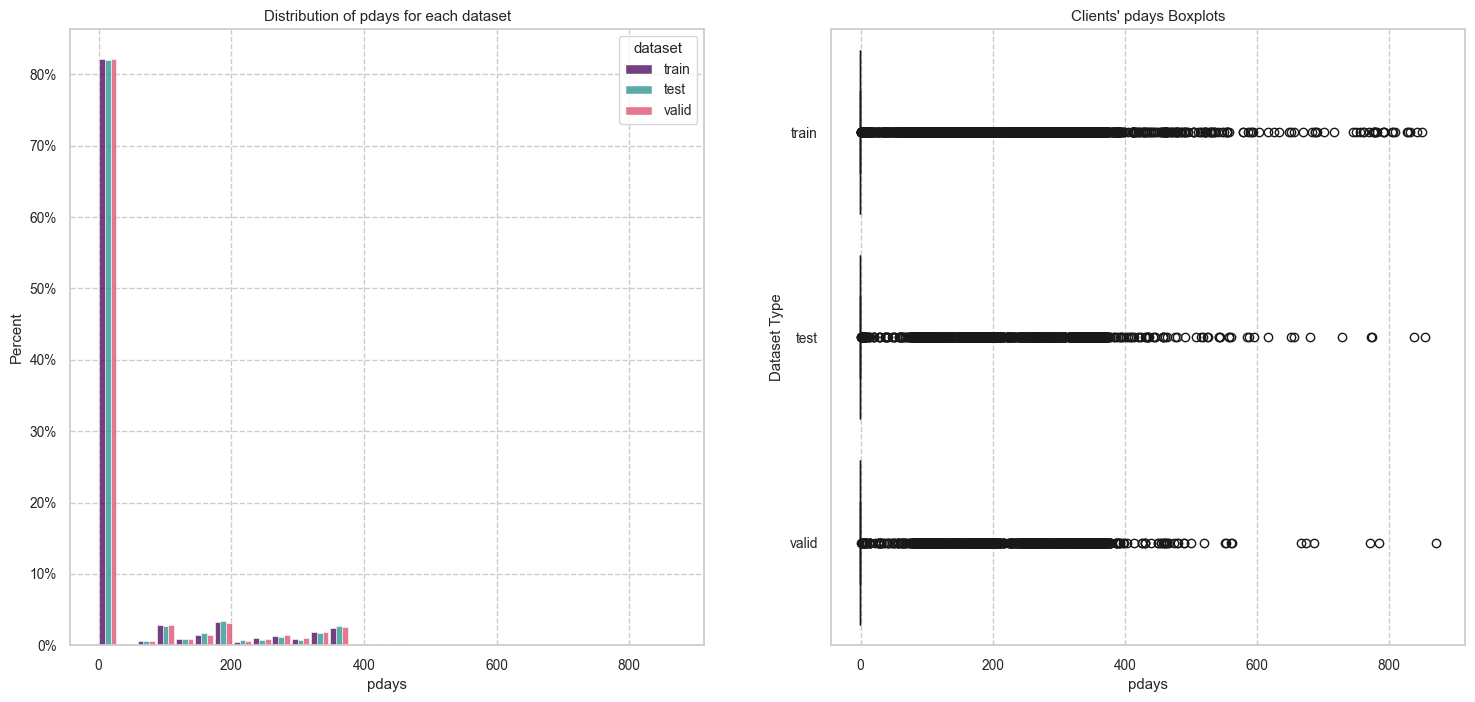

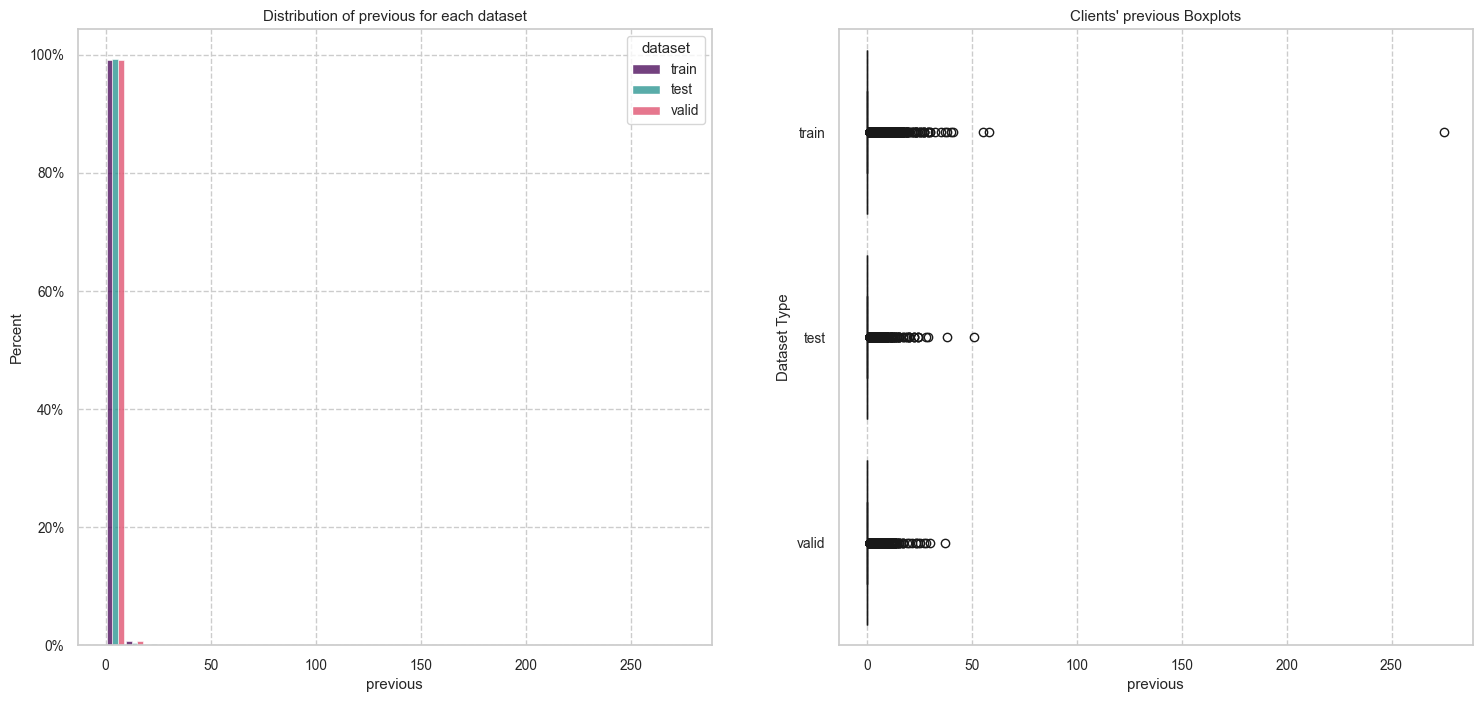

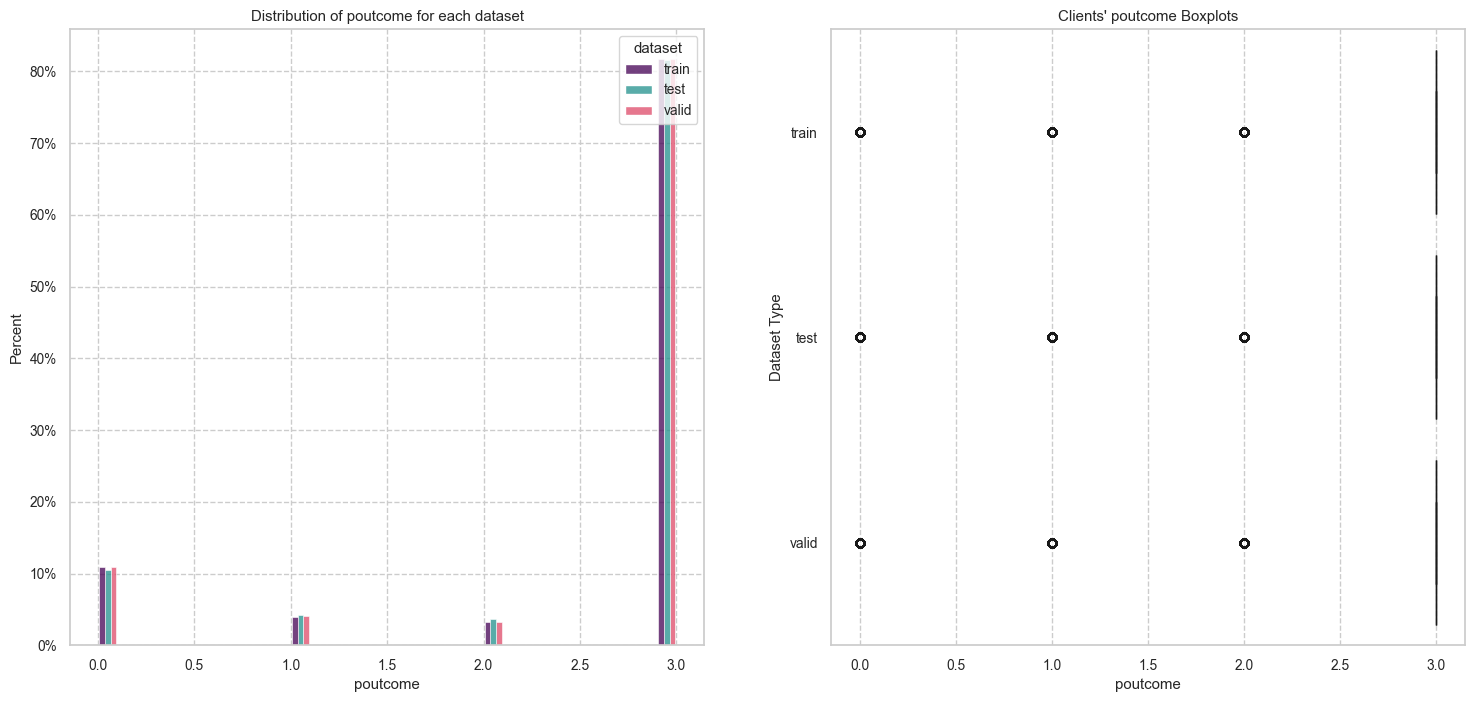

In [38]:
for col in X_test.columns.drop(['dataset']):
    fig, axs = plt.subplots(1, 2, figsize=(18, 8))
    draw_histogram(col, ax=axs[0])
    draw_boxplots(col, ax=axs[1])
    axs[0].set_title(f"Distribution of {col} for each dataset")
    plt.show()

### 3.2.3 Wnioski

Analizowana baza obejmuje głównie osoby około 40. roku życia, zdominowane przez pracowników fizycznych, menedżerów oraz techników. Większość z nich to osoby z wykształceniem średnim lub wyższym, będące w związkach małżeńskich lub po rozwodzie. 

Pod kątem finansowym zbiór charakteryzuje się ogromną asymetrią: niemal cała próba rzetelnie spłaca zobowiązania (brak przypadków default), a roczne saldo (balance) cechuje gigantyczny rozrzut (odchylenie standardowe przekracza 3064 EUR, przy maksimum ponad 102 tys. EUR), co na boxplotach generuje potężną liczbę wartości odstających. Ponad połowa klientów (55,6%) posiada kredyt hipoteczny, podczas gdy tradycyjne pożyczki gotówkowe są rzadkością (16%). 

Sama kampania telefoniczna, której szczyt przypadał na sierpień, była dla większości klientów pierwszym kontaktem z bankiem (ponad 80% wartości -1 dla pdays oraz dominacja zer dla previous). Zarówno czas trwania rozmowy (duration, średnio ok. 258 sekund, maks. 1,3 godziny), jak i liczba prób kontaktu (średnio 1–3, maks. aż 63) wykazują silną obecność outlierów. Całość dopełnia zmienna wynikowa y, która jest silnie niezbalansowana – sukcesem (zgodą na lokatę) zakończyło się zaledwie 11,7% interwencji.

Co kluczowe z punktu widzenia dalszego modelowania, przeprowadzona analiza wizualna potwierdza, że rozkłady zmiennych są spójne we wszystkich zbiorach. Oznacza to, że dobry model przygotowany na zbiorze treningowym powinien zachować wysoką jakość predykcji również na zbiorze testowym.

# 4. Analiza zależności zmiennej docelowej 'y' ze zmiennymi objaśniającymi

Ostatnim etapem analizy jest weryfikacja wpływu poszczególnych predyktorów na zmienną docelową „y” w podziale na zbiory danych. Na wykresach zestawiono liczebność poszczególnych kategorii zmiennej niezależnej (słupki) z odpowiadającą im średnią wartością zmiennej celu (znaczniki). Dzięki temu możemy potwierdzić, czy predyktor wpływa na zmieną celu oraz że trendy zaobserwowane w danych treningowych znajdują odzwierciedlenie w zbiorze testowym i walidacyjnym. 

Dla zmiennych ciągłych zastosowano podział na przedziały (binning), co umożliwiło wyodrębnienie grup i analizę wpływu zakresów wartości na zmienną objaśnianą.

In [25]:
df_all['previous_capped'] = df_all['previous'].clip(upper=3)
df_all['pdays_capped'] = df_all['pdays'].clip(upper=0)

continous_vars_1 = ['age', 'balance', 'day', 'duration', 'campaign']
discrete_vars =  df_all.columns.drop(continous_vars_1 + ['dataset', 'previous', 'pdays', 'y'])

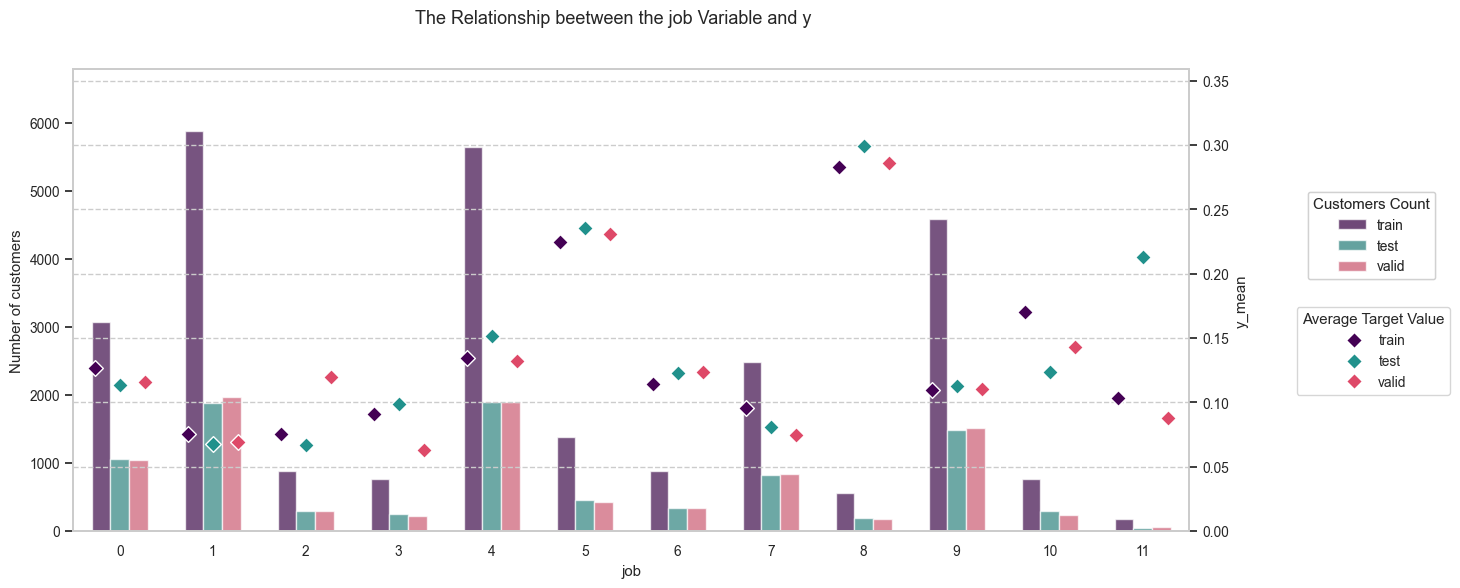

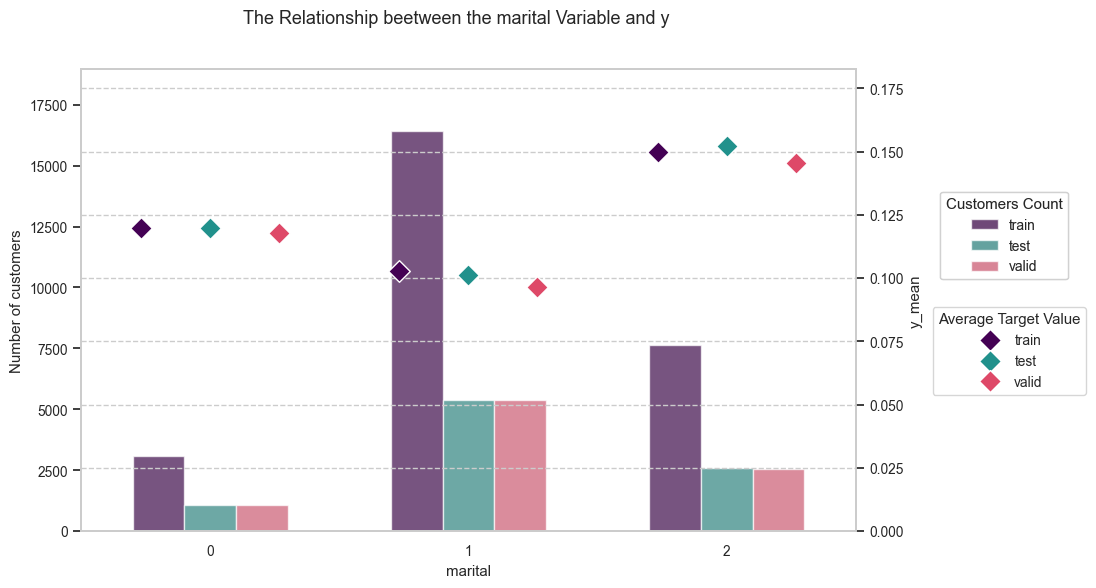

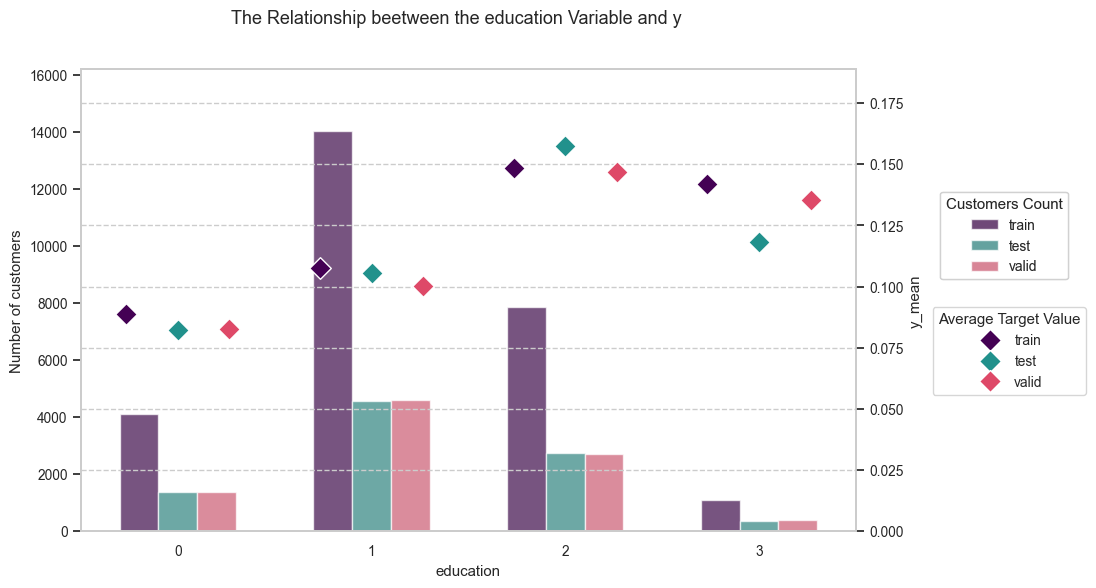

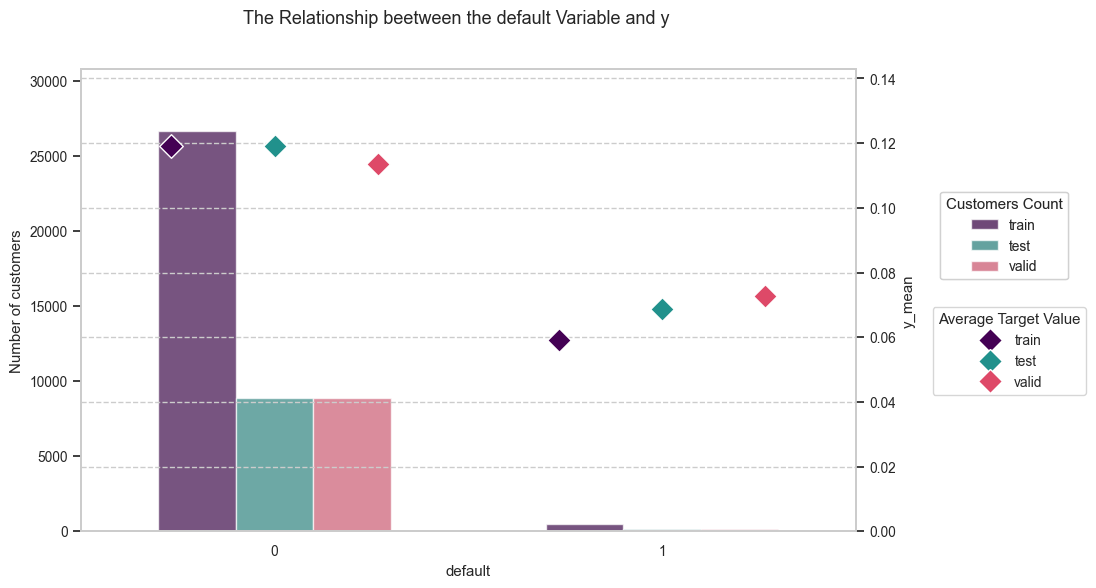

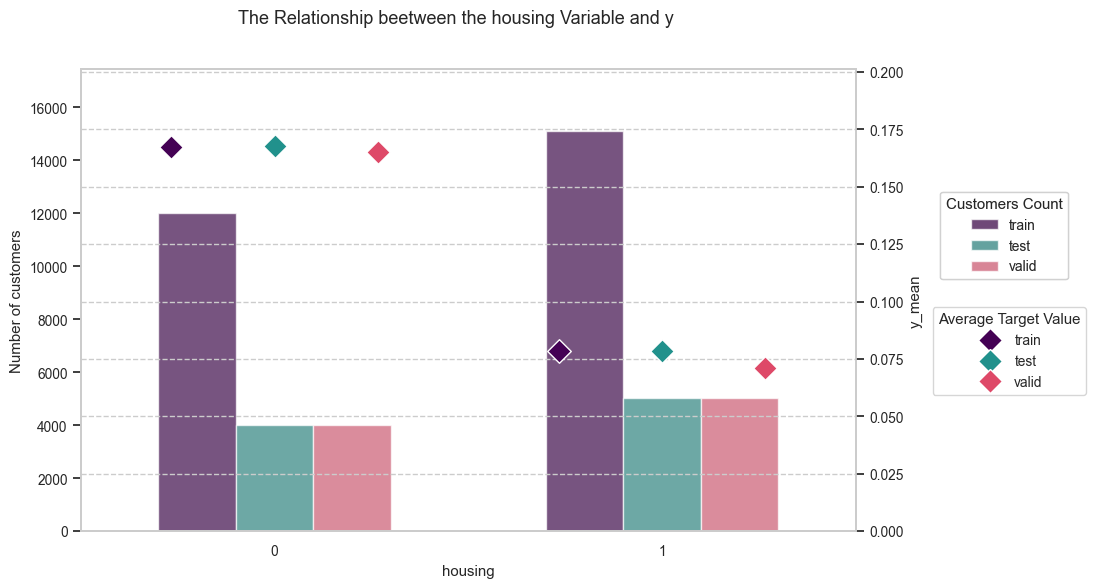

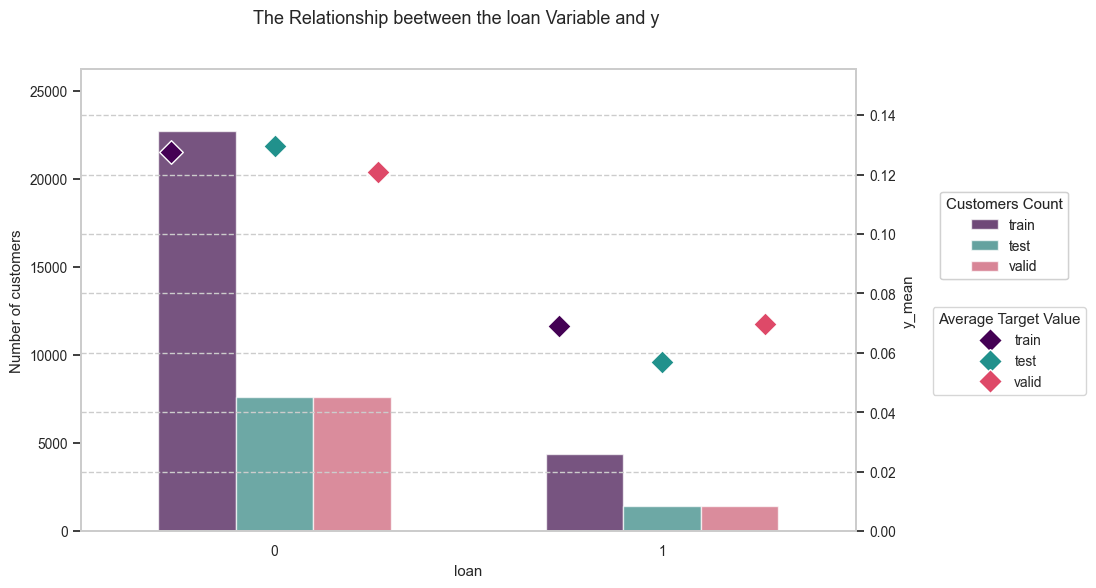

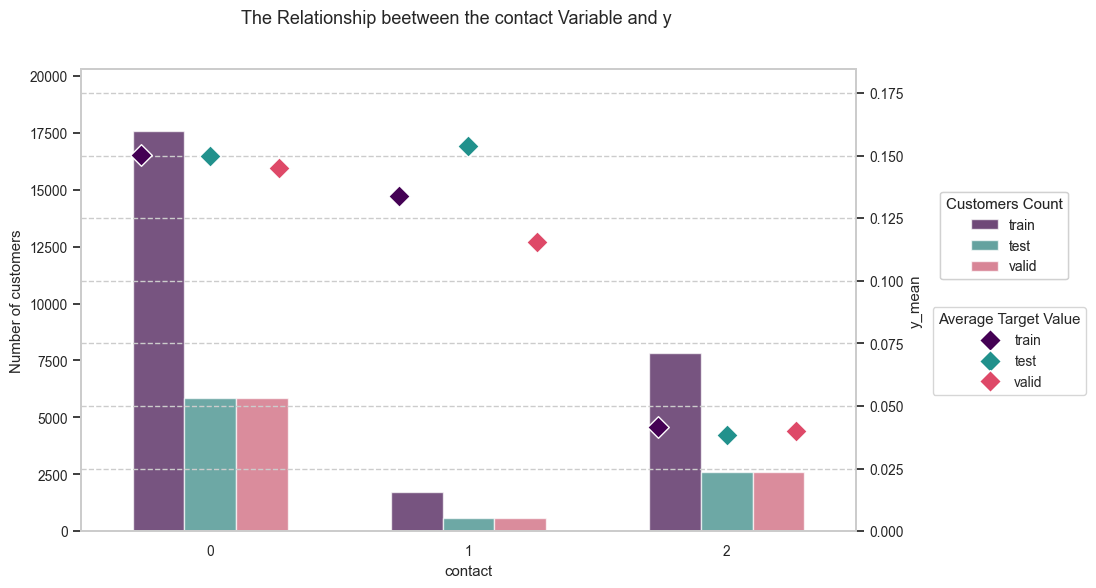

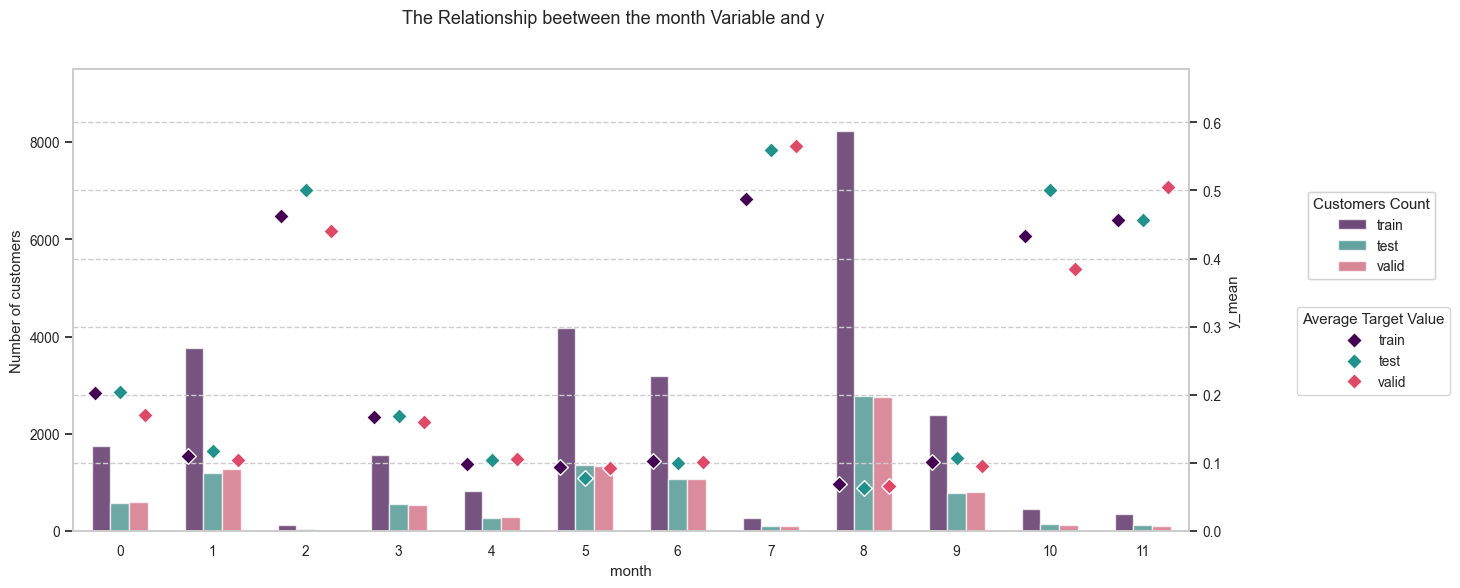

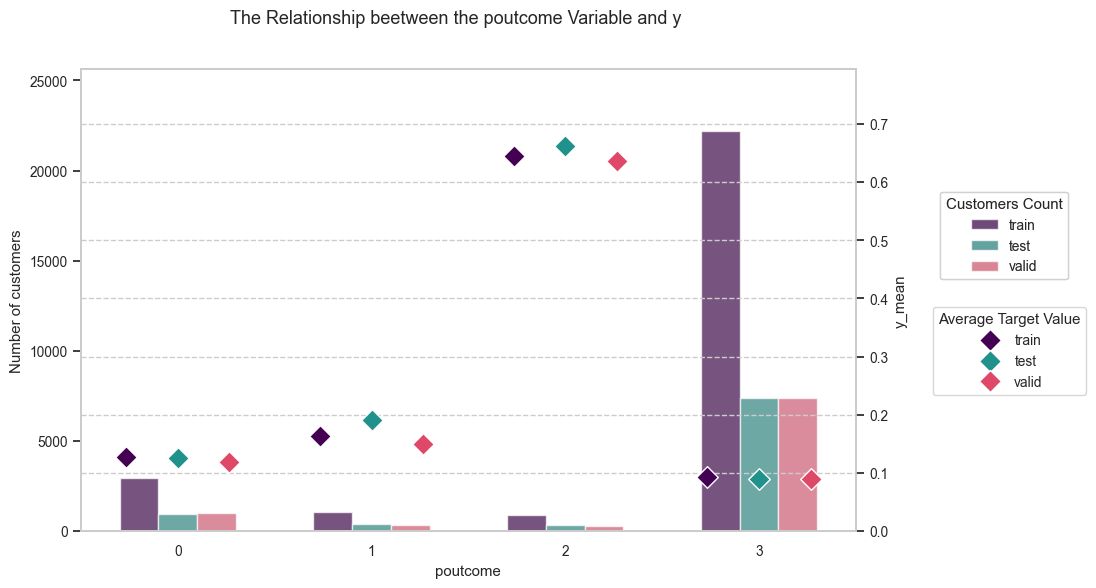

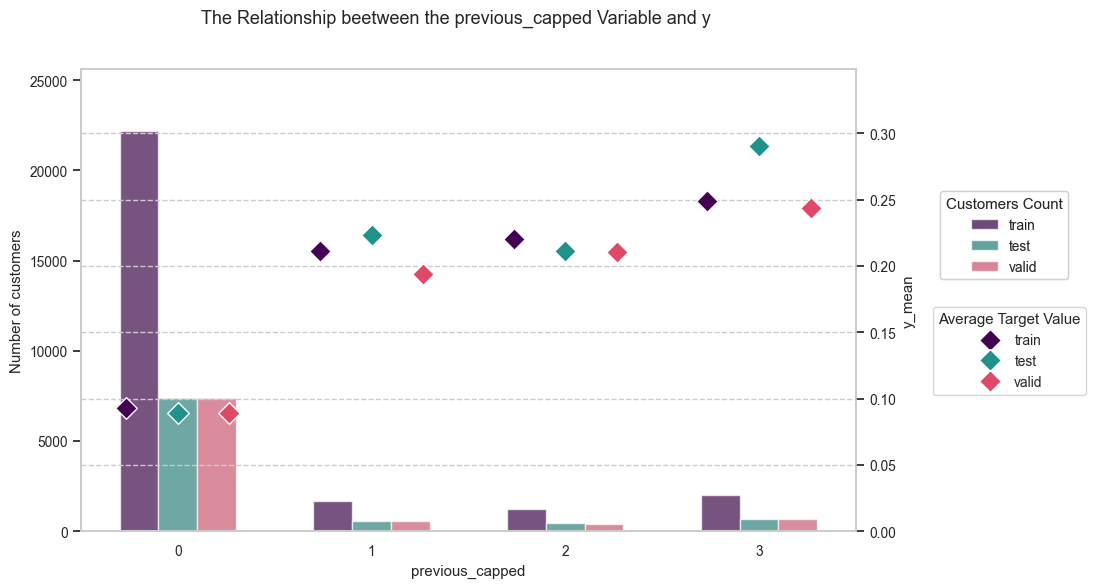

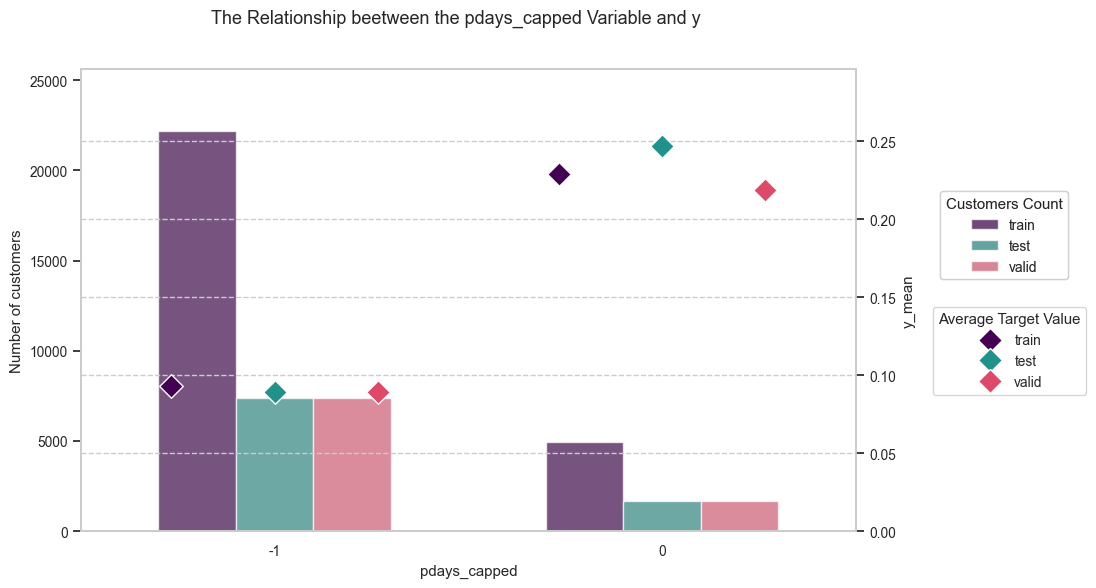

In [26]:
for var in discrete_vars:
    draw_relationship_var_and_target(var = var)

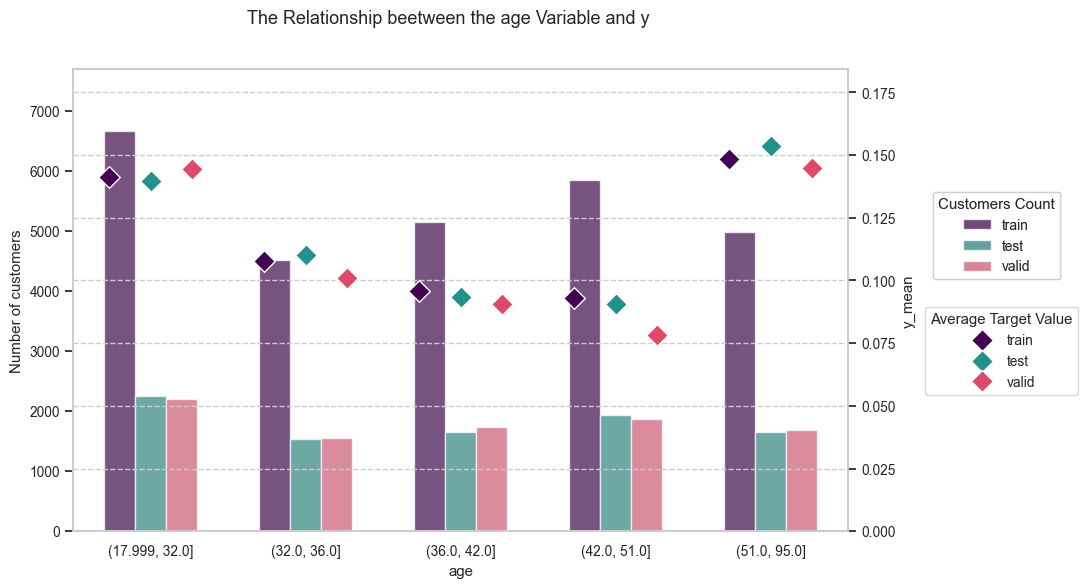

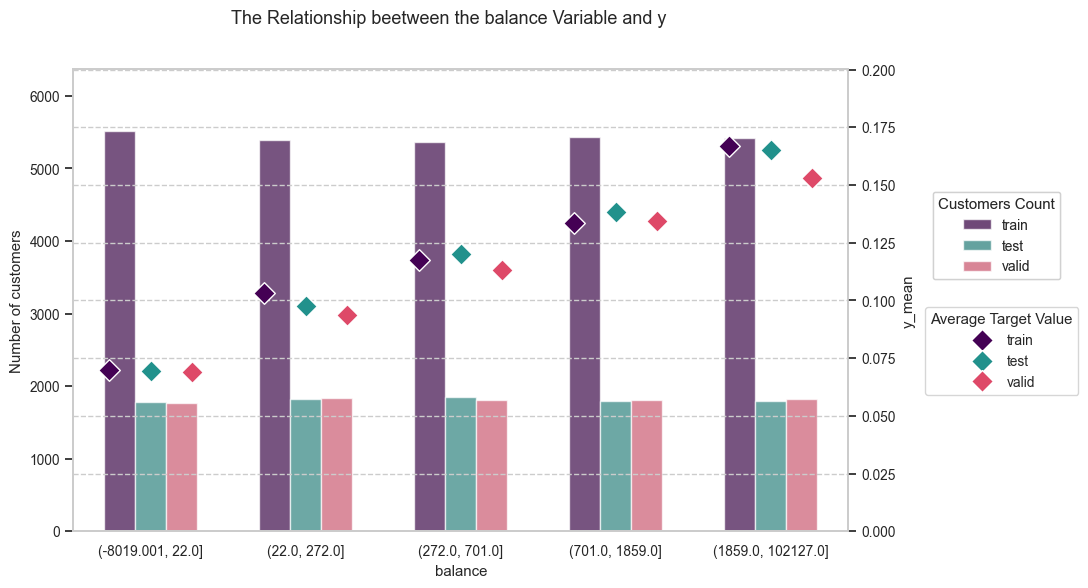

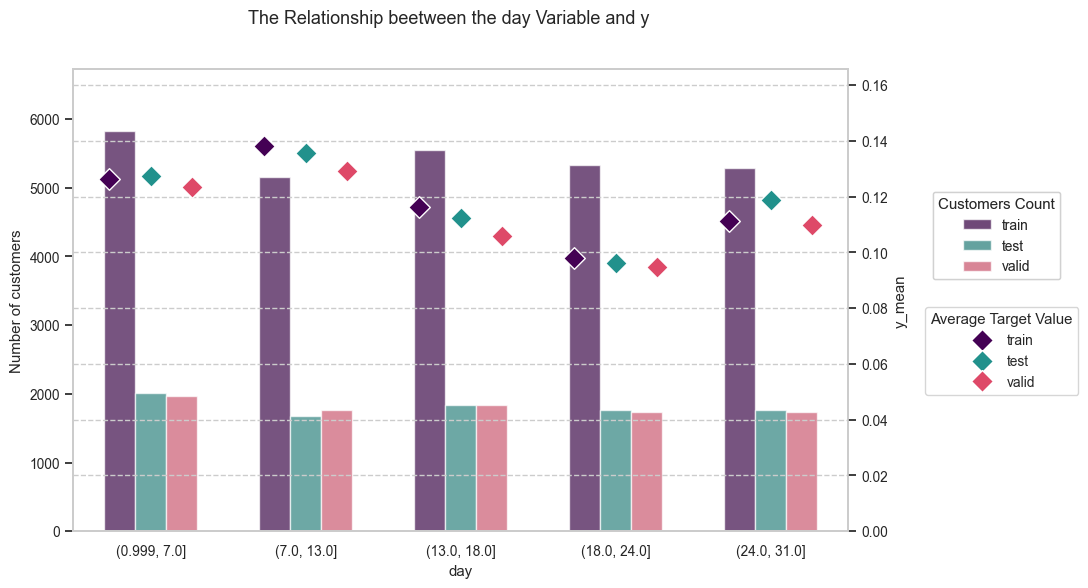

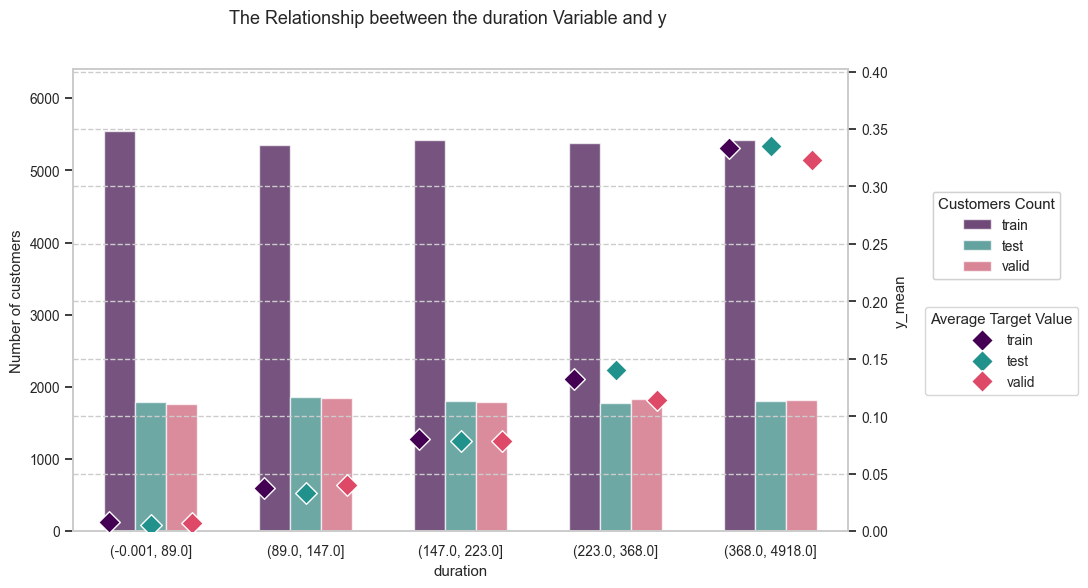

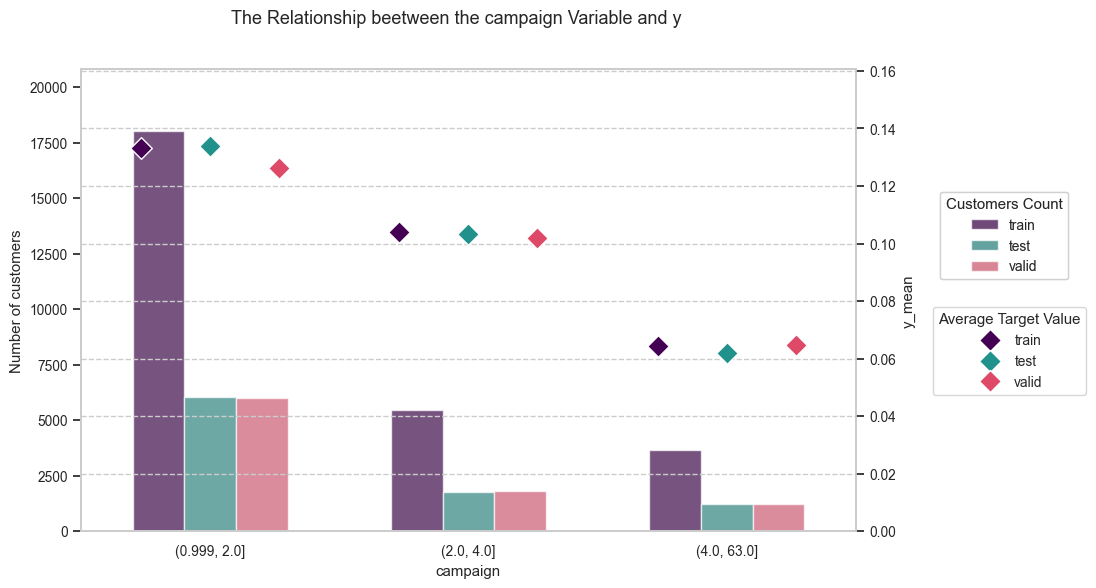

In [27]:
for var in continous_vars_1:
    draw_relationship_var_and_target(var = var, type_of_var = 'continous')

Wykresy ujawniły grupę silnych predyktorów o kluczowym znaczeniu predykcyjnym:

* **Czas trwania rozmowy (duration)** i **intensywność kontaktu (campaign)**: Zmienne operacyjne wykazują skrajnie silny, ale odwrotny wpływ na target. Szansa na sukces rośnie monotonicznie wraz z wydłużaniem czasu rozmowy. Z kolei liczba kontaktów w obecnej kampanii jest ujemnie skorelowana z sukcesem – im więcej prób połączeń, tym mniejsza średnia wartość y, co sugeruje, że optymalne jest domykanie sprzedaży przy pierwszych 1–3 kontaktach.

* **Status finansowy (balance, housing, loan, default)**: Wyższe średnie saldo roczne wydatnie zwiększa prawdopodobieństwo założenia lokaty. Klienci wolni od zobowiązań kredytowych (brak kredytu gotówkowego lub hipotecznego) wykazują znacznie wyższy wskaźnik sukcesu, co potwierdza hipotezę, że osoby nieobciążone długami chętniej alokują nadwyżki finansowe. W przypadku zmiennej default brak zaległości wiąże się z wyższym y, jednak z uwagi na silne niezbalansowanie tej cechy, wnioskowanie dla osób z zaległościami obarczone jest ryzykiem błędu z powodu małej liczby obserwacji.

* **Historia współpracy (pdays, previous, poutcome)**: Fakt zaistnienia wcześniejszego kontaktu w przeszłości znacząco podnosi prawdopodobieństwo sukcesu w obecnej kampanii, a im krótszy czas upłynął od ostatniej akcji (pdays), tym wyższy wskaźnik konwersji. Kluczowym predyktorem jest wynik poprzedniej kampanii (poutcome) – jeśli zakończyła się ona sukcesem, szansa na ponowne wykupienie produktu jest najwyższa. Należy jednak pamiętać, że dla wyższych wartości pdays i previous próba jest nieliczna, co może powodować lokalne wahania i niestabilność średniej.

Pozostałe zmienne wykazują umiarkowany lub nieliniowy wpływ na zmienną celu:
* **Wiek (age)**: Wpływ wieku ma charakter nieliniowy (w kształcie litery U). W przedziale od 18 do 51 lat prawdopodobieństwo zakupu produktu maleje wraz z wiekiem, natomiast w najstarszej grupie (51–95 lat) drastycznie rośnie.

* **Dzień kontaktu (day) i kanał komunikacji (contact)**: Dzień miesiąca wykazuje stabilny wpływ (konwersja na poziomie 12–14%) do około 20. dnia, po czym następuje spadek efektywności i ponowne odbicie pod sam koniec miesiąca. W przypadku kanału komunikacji wyższą skutecznością cieszą się określone, bezpośrednie formy kontaktu, podczas gdy brak danych o kanale drastycznie obniża średni wskaźnik y.

* **Stan cywilny (marital)**: Cecha ta wykazuje najsłabszy wpływ na zmienną celu, choć można zauważyć delikatną nadwyżkę skuteczności wśród osób rozwiedzionych w porównaniu do singli i osób w związkach małżeńskich.

Co najistotniejsze, wszystkie zaobserwowane trendy, zależności i kierunki korelacji są w spójne pomiędzy zbiorem treningowym, testowym i walidacyjnym (jedyne rozbieżności pojawiają się przy mniej licznych kategoriach), co potwierdza stabilność struktury danych i gwarantuje wysoką zdolność generalizacji przyszłych modeli predykcyjnych.

# Podsumowanie

Podsumowując przeprowadzone analizy, zgromadzony zbiór danych wykazuje bardzo wysoki potencjał predykcyjny. Zidentyfikowane podczas eksloracji danych silne zależności oraz wyraźne korelacje (wpływ zmiennych duration, campaign czy statusu kredytowego) tworzą dobrą bazę dla algorytmu XGBoost.

Wszystkie kluczowe zależności i trendy zaobserwowane w podzbiorze treningowym znalazły idealne odzwierciedlenie w próbie testowej i walidacyjnej, co ostatecznie potwierdza stabilność struktury danych. W rezultacie dane są w pełni gotowe do modelowania. W kolejnej części raportu przeprowadzimy selekcję cech mającą na celu eliminację współliniowości w obszarze zmiennych historycznych, a następnie przeprowadzimy optymalizację hiperparametrów i właściwy trening klasyfikatora XGBoost.